# Chapter 2: First-Order Differential Equations
## Complete Instructor Interactive Notebook

In [1]:
# Classroom setup — run once.
import base64
import importlib.util
import platform
import sys

_REQUIRED = ["numpy", "matplotlib", "scipy", "sympy", "ipywidgets"]
_missing = [name for name in _REQUIRED if importlib.util.find_spec(name) is None]

print(f"Python {sys.version.split()[0]} on {platform.system()}")
if _missing:
    print("Missing package(s):", ", ".join(_missing))
    print("Install with: python -m pip install -r requirements.txt")
else:
    print("Notebook environment is ready.")

import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

from scipy.integrate import solve_ivp, quad
from scipy.special import erf
from IPython.display import display, Markdown, Math, clear_output

try:
    import ipywidgets as widgets
    from ipywidgets import ToggleButton, Output, VBox, Layout, FloatSlider, IntSlider, interact
    WIDGETS_AVAILABLE = True
except ImportError:
    WIDGETS_AVAILABLE = False

    def FloatSlider(*args, value=0.0, **kwargs):
        return value

    def IntSlider(*args, value=0, **kwargs):
        return value

    def interact(function, **kwargs):
        values = {key: getattr(obj, "value", obj) for key, obj in kwargs.items()}
        function(**values)
        return None

plt.rcParams["figure.figsize"] = (9, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

def _reveal_button(encoded_answer, label="Reveal solution"):
    if not WIDGETS_AVAILABLE:
        display(Markdown(
            "**Reveal button unavailable.** Install `ipywidgets`, restart the kernel, "
            "and run this cell again."
        ))
        return

    button = ToggleButton(
        value=False,
        description=label,
        button_style="info",
        icon="eye",
        layout=Layout(width="190px", height="40px")
    )
    out = Output(layout=Layout(
        width="98%",
        border="1px solid #dddddd",
        padding="10px"
    ))

    def _toggle(change):
        with out:
            clear_output()
            if change["new"]:
                answer = base64.b64decode(encoded_answer).decode("utf-8")
                display(Markdown(answer))
                button.description = "Hide solution"
                button.icon = "eye-slash"
            else:
                button.description = label
                button.icon = "eye"

    button.observe(_toggle, names="value")
    display(VBox([button, out]))

def _show_problem(number, equation_latex, question_markdown, encoded_answer):
    display(Markdown(f"### Problem {number}"))
    display(Math(r"\displaystyle " + equation_latex))
    if question_markdown:
        display(Markdown(question_markdown))
    _reveal_button(encoded_answer, label=f"Reveal #{number}")

def slope_field(f, xlim=(-4,4), ylim=(-4,4), density=23, title=None):
    xs = np.linspace(*xlim, density)
    ys = np.linspace(*ylim, density)
    X, Y = np.meshgrid(xs, ys)
    S = np.asarray(f(X, Y), dtype=float)
    U = np.ones_like(S)
    V = S.copy()
    N = np.sqrt(U**2 + V**2)
    U, V = U/N, V/N

    plt.figure(figsize=(9, 6))
    q = plt.quiver(X, Y, U, V, S, cmap="coolwarm", pivot="mid")
    plt.xlim(xlim)
    plt.ylim(ylim)
    plt.xlabel("$x$")
    plt.ylabel("$y$")
    if title:
        plt.title(title)
    plt.colorbar(q, label="slope")
    plt.show()

def euler_method(f, x0, y0, h, n_steps):
    xs = [float(x0)]
    ys = [float(y0)]
    for _ in range(n_steps):
        xs.append(xs[-1] + h)
        ys.append(ys[-1] + h*f(xs[-1], ys[-1]))
    return np.array(xs), np.array(ys)

def show_21_phase_line_check():
    _show_problem(
        1,
        r"y'=(y+2)(y-1)^2(y-4)",
        "Identify all equilibria and classify each as stable, unstable, or semistable.",
        "IyMjIFNvbHV0aW9uCgpFcXVpbGlicmlhIG9jY3VyIHdoZXJlCgokJAooeSsyKSh5LTEpXjIoeS00KT0wLgokJAoKVGh1cwoKJCQKeT0tMixccXF1YWQgeT0xLFxxcXVhZCB5PTQuCiQkCgpDaGVjayB0aGUgc2lnbiBvZgoKJCQKZih5KT0oeSsyKSh5LTEpXjIoeS00KS4KJCQKCkJlY2F1c2UgJCh5LTEpXjJcZ2UwJCwgdGhlIHNpZ24gY2hhbmdlcyBvbmx5IGF0ICR5PS0yJCBhbmQgJHk9NCQuCgotIEZvciAkeTwtMiQsICRmKHkpPjAkOiBhcnJvd3MgcG9pbnQgdXB3YXJkLgotIEZvciAkLTI8eTwxJCwgJGYoeSk8MCQ6IGFycm93cyBwb2ludCBkb3dud2FyZC4KLSBGb3IgJDE8eTw0JCwgJGYoeSk8MCQ6IGFycm93cyBzdGlsbCBwb2ludCBkb3dud2FyZC4KLSBGb3IgJHk+NCQsICRmKHkpPjAkOiBhcnJvd3MgcG9pbnQgdXB3YXJkLgoKVGhlcmVmb3JlCgokJApcYm94ZWR7eT0tMlx0ZXh0eyBpcyBzdGFibGV9fSwKJCQKCiQkClxib3hlZHt5PTFcdGV4dHsgaXMgc2VtaXN0YWJsZX19LAokJAoKYW5kCgokJApcYm94ZWR7eT00XHRleHR7IGlzIHVuc3RhYmxlfX0uCiQk"
    )

def show_21_cubic_check():
    _show_problem(
        1,
        r"y'=y(y+1)(3-y)",
        "Before looking at the graph, predict the phase-line arrows and classify the three equilibria.",
        "IyMjIFNvbHV0aW9uCgpGb3IKCiQkCnknPXkoeSsxKSgzLXkpLAokJAoKdGhlIGVxdWlsaWJyaWEgYXJlCgokJAp5PS0xLFxxcXVhZCB5PTAsXHFxdWFkIHk9My4KJCQKClRoZSBzaWduIHBhdHRlcm4gaXMKCiQkCitcO3xcOy1cO3xcOytcO3xcOy0KJCQKCm9uIHRoZSBpbnRlcnZhbHMKCiQkCigtXGluZnR5LC0xKSxccXVhZCgtMSwwKSxccXVhZCgwLDMpLFxxdWFkKDMsXGluZnR5KS4KJCQKCkhlbmNlCgokJApcYm94ZWR7LTFcdGV4dHsgc3RhYmxlfSxccXVhZCAwXHRleHR7IHVuc3RhYmxlfSxccXVhZCAzXHRleHR7IHN0YWJsZX0ufQokJA=="
    )

def show_22_checkpoint():
    _show_problem(
        1,
        r"y'=x(y-3)^2",
        "Solve the equation and make sure no constant solution is lost during separation.",
        "IyMjIFNvbHV0aW9uCgpGaXJzdCBpZGVudGlmeSBlcXVpbGlicml1bSBzb2x1dGlvbnMgYmVmb3JlIGRpdmlkaW5nLgoKVGhlIGZhY3RvcgoKJCQKKHktMyleMgokJAoKdmFuaXNoZXMgd2hlbgoKJCQKeT0zLAokJAoKc28KCiQkClxib3hlZHt5XGVxdWl2M30KJCQKCmlzIGEgY29uc3RhbnQgc29sdXRpb24uCgpGb3Igbm9uY29uc3RhbnQgc29sdXRpb25zLAoKJCQKXGZyYWN7ZHl9eyh5LTMpXjJ9PXhcLGR4LgokJAoKSW50ZWdyYXRlOgoKJCQKLVxmcmFjezF9e3ktM309XGZyYWN7eF4yfXsyfStDLgokJAoKSGVuY2UKCiQkCnk9My1cZnJhY3sxfXt4XjIvMitDfS4KJCQKClRoZSBjb21wbGV0ZSBhbnN3ZXIgbXVzdCBpbmNsdWRlIGJvdGggdGhlIG5vbmNvbnN0YW50IGZhbWlseSBhbmQgdGhlIGVxdWlsaWJyaXVtICR5PTMkLg=="
    )

def show_23_checkpoint():
    _show_problem(
        1,
        r"(1+x)y'+2y=x^2",
        "Put the equation in standard form, identify the singular point, and find an integrating factor on $x>-1$.",
        "IyMjIFNvbHV0aW9uCgpEaXZpZGUgYnkgJDEreCQ6CgokJAp5JytcZnJhY3syfXsxK3h9eT1cZnJhY3t4XjJ9ezEreH0uCiQkCgpUaHVzIHRoZSBzaW5ndWxhciBwb2ludCBpcwoKJCQKXGJveGVke3g9LTF9LgokJAoKT24gJHg+LTEkLAoKJCQKUCh4KT1cZnJhY3syfXsxK3h9LAokJAoKc28gYW4gaW50ZWdyYXRpbmcgZmFjdG9yIGlzCgokJApcbXUoeCkKPQplXntcaW50IDIvKDEreClcLGR4fQo9CmVeezJcbG4oMSt4KX0KPQpcYm94ZWR7KDEreCleMn0uCiQk"
    )

def show_24_checkpoint():
    _show_problem(
        1,
        r"(2x+y\cos x)\,dx+(\sin x+3y^2)\,dy=0",
        "Determine whether the equation is exact. If it is exact, find the implicit solution.",
        "IyMjIFNvbHV0aW9uCgpIZXJlCgokJApNKHgseSk9MngreVxjb3MgeCwKJCQKCmFuZAoKJCQKTih4LHkpPVxzaW4geCszeV4yLgokJAoKRGlmZmVyZW50aWF0ZToKCiQkCk1feT1cY29zIHgsCiQkCgphbmQKCiQkCk5feD1cY29zIHguCiQkCgpUaGVyZWZvcmUKCiQkCk1feT1OX3gsCiQkCgpzbyB0aGUgZGlmZmVyZW50aWFsIGVxdWF0aW9uIGlzIGV4YWN0IG9uIGV2ZXJ5IHJlY3Rhbmd1bGFyIHJlZ2lvbiBpbiB0aGUgcGxhbmUuCgpUbyByZWNvdmVyIGEgcG90ZW50aWFsICRGJCwgaW50ZWdyYXRlICRNJCB3aXRoIHJlc3BlY3QgdG8gJHgkOgoKJCQKRih4LHkpPXheMit5XHNpbiB4K2coeSkuCiQkCgpEaWZmZXJlbnRpYXRlIHdpdGggcmVzcGVjdCB0byAkeSQ6CgokJApGX3k9XHNpbiB4K2cnKHkpLgokJAoKU2V0IHRoaXMgZXF1YWwgdG8gJE4kOgoKJCQKXHNpbiB4K2cnKHkpPVxzaW4geCszeV4yLgokJAoKSGVuY2UKCiQkCmcnKHkpPTN5XjIsCiQkCgpzbwoKJCQKZyh5KT15XjMuCiQkCgpUaGVyZWZvcmUgdGhlIGltcGxpY2l0IHNvbHV0aW9uIGlzCgokJApcYm94ZWR7eF4yK3lcc2luIHgreV4zPUMufQokJA=="
    )

def show_25_checkpoint():
    _show_problem(
        1,
        r"y'=(3x-2y+1)^3",
        "Choose a substitution that simplifies the equation, and show the transformed differential equation.",
        "IyMjIFNvbHV0aW9uCgpUaGUgZGVyaXZhdGl2ZSBkZXBlbmRzIG9uIHRoZSBsaW5lYXIgY29tYmluYXRpb24KCiQkCjN4LTJ5KzEuCiQkCgpVc2UKCiQkClxib3hlZHt1PTN4LTJ5KzEufQokJAoKRGlmZmVyZW50aWF0ZToKCiQkCnUnPTMtMnknLgokJAoKU2luY2UKCiQkCnknPXVeMywKJCQKCndlIG9idGFpbgoKJCQKdSc9My0ydV4zLgokJAoKVGhpcyBpcyBhdXRvbm9tb3VzIGFuZCB0aGVyZWZvcmUgc2VwYXJhYmxlOgoKJCQKXGZyYWN7ZHV9ezMtMnVeM309ZHguCiQkCgpUaGUgaW1wb3J0YW50IHBvaW50IGlzIHRoZSBzdHJ1Y3R1cmFsIHJlY29nbml0aW9uOiB0aGUgc3Vic3RpdHV0aW9uIGNvbnZlcnRzIHRoZSBvcmlnaW5hbCBlcXVhdGlvbiBpbnRvIGEgc2VwYXJhYmxlIGVxdWF0aW9uLg=="
    )

def show_26_checkpoint():
    _show_problem(
        1,
        r"y'=-5y",
        "For Euler's method, determine the strict step-size stability condition.",
        "IyMjIFNvbHV0aW9uCgpFdWxlcidzIG1ldGhvZCBnaXZlcwoKJCQKeV97bisxfT15X24raCgtNXlfbikKPQooMS01aCl5X24uCiQkCgpGb3Igc3RyaWN0IGRlY2F5IHdpdGhvdXQgbnVtZXJpY2FsIGdyb3d0aCwgcmVxdWlyZQoKJCQKfDEtNWh8PDEuCiQkCgpUaHVzCgokJAotMTwxLTVoPDEuCiQkCgpTdWJ0cmFjdCAkMSQ6CgokJAotMjwtNWg8MC4KJCQKCkRpdmlkZSBieSAkLTUkIGFuZCByZXZlcnNlIHRoZSBpbmVxdWFsaXRpZXM6CgokJAowPGg8XGZyYWMyNS4KJCQKClRoZXJlZm9yZQoKJCQKXGJveGVkezA8aDwwLjR9LgokJAoKVGhlIGJvdW5kYXJ5IHZhbHVlICRoPTAuNCQgZ2l2ZXMgYW1wbGlmaWNhdGlvbiBmYWN0b3IgJC0xJCwgc28gaXQgaXMgbm90IGluY2x1ZGVkIGluIHRoZSBzdHJpY3Qgc3RhYmlsaXR5IGludGVydmFsLg=="
    )

Python 3.13.15 on Linux
Notebook environment is ready.


# Section 2.1: Solution Curves Without Solving the Equation

## 1. Direction fields as local slope maps

For a first-order equation

$$
y'=f(x,y),
$$

the number $f(x,y)$ is the slope that every solution curve must have when it passes through $(x,y)$.

A **direction field** places a short line segment with that slope at many points.  
The field lets us predict the shape of solutions before solving the equation.

Consider

$$
\boxed{y'=x-y.}
$$

The zero-slope set is obtained from

$$
x-y=0,
$$

so

$$
y=x.
$$

Hence:

- below $y=x$, we have $x-y>0$, so solution curves increase;
- above $y=x$, we have $x-y<0$, so solution curves decrease;
- on $y=x$, the instantaneous slope is zero.

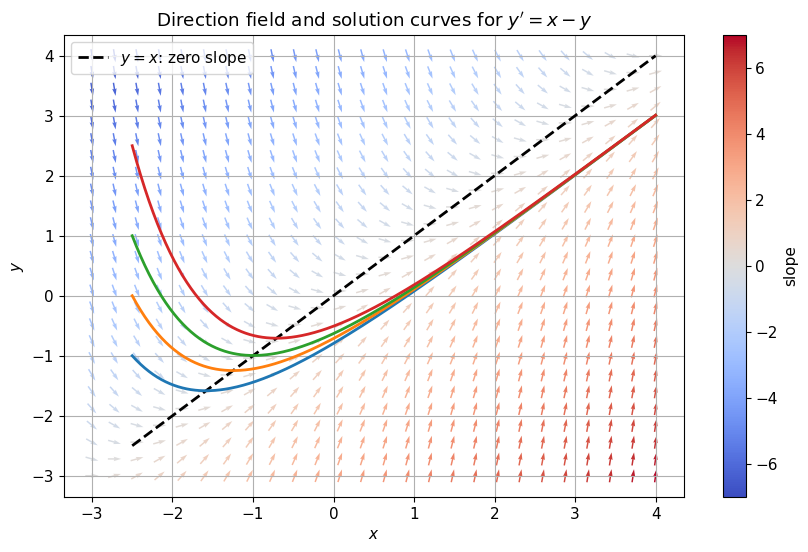

In [2]:
def f1(x, y):
    return x-y

xs = np.linspace(-3, 4, 26)
ys = np.linspace(-3, 4, 26)
X, Y = np.meshgrid(xs, ys)
S = X-Y
U = np.ones_like(S)
V = S.copy()
N = np.sqrt(U**2+V**2)
U, V = U/N, V/N

plt.figure(figsize=(10,6))
q = plt.quiver(X,Y,U,V,S,cmap="coolwarm",pivot="mid")
xx = np.linspace(-2.5,4,500)
plt.plot(xx,xx,"k--",linewidth=2,label=r"$y=x$: zero slope")
for y0 in [-1,0,1,2.5]:
    sol = solve_ivp(lambda x,y:[x-y[0]],(-2.5,4),[y0],dense_output=True,
                    rtol=1e-9,atol=1e-11)
    grid = np.linspace(-2.5,4,500)
    plt.plot(grid,sol.sol(grid)[0],linewidth=2)
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.title(r"Direction field and solution curves for $y'=x-y$")
plt.colorbar(q,label="slope")
plt.legend()
plt.show()

## 2. Nullclines and sign regions

A **nullcline** for

$$
y'=f(x,y)
$$

is a curve on which

$$
f(x,y)=0.
$$

Along a nullcline, the direction-field segments are horizontal.

For

$$
y'=0.3xy,
$$

the nullclines are

$$
x=0
\qquad\text{and}\qquad
y=0.
$$

The signs of $x$ and $y$ determine whether solutions increase or decrease.

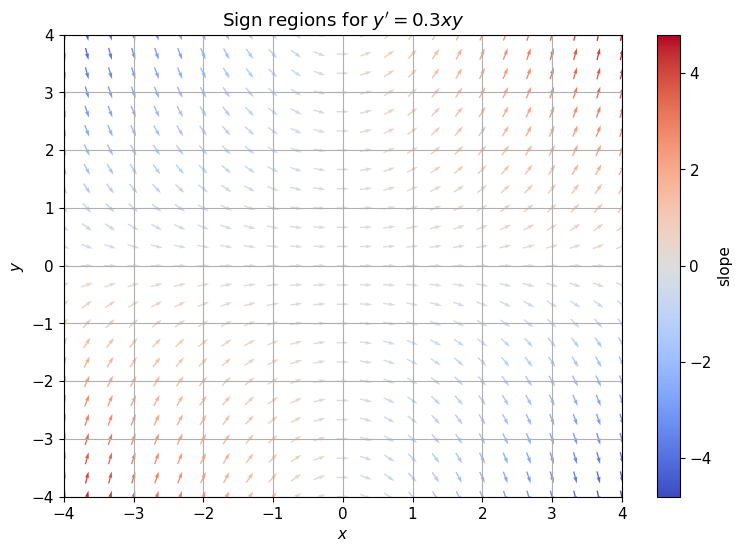

In [3]:
slope_field(
    lambda x,y: 0.3*x*y,
    xlim=(-4,4),
    ylim=(-4,4),
    density=25,
    title=r"Sign regions for $y'=0.3xy$"
)

## 3. Autonomous equations and equilibria

An equation is **autonomous** when the independent variable does not appear explicitly:

$$
\boxed{y'=f(y).}
$$

An **equilibrium solution** is a constant solution

$$
y(x)\equiv c
$$

for which

$$
f(c)=0.
$$

For autonomous equations, the sign of $f(y)$ determines the direction of motion:

$$
f(y)>0
\quad\Longrightarrow\quad
y'>0
\quad\Longrightarrow\quad
\text{solutions move upward},
$$

while

$$
f(y)<0
\quad\Longrightarrow\quad
\text{solutions move downward}.
$$

## 4. Phase-line analysis

Consider

$$
\boxed{y'=y(y+1)(3-y).}
$$

The equilibria satisfy

$$
y(y+1)(3-y)=0,
$$

so

$$
y=-1,\qquad y=0,\qquad y=3.
$$

Choose one test value in each interval.

$$
\renewcommand{\arraystretch}{1.55}
\begin{array}{|c|c|c|}
\hline
\textbf{Interval} & \textbf{Sign of }f(y) & \textbf{Direction} \\
\hline
(-\infty,-1) & + & \uparrow \\
\hline
(-1,0) & - & \downarrow \\
\hline
(0,3) & + & \uparrow \\
\hline
(3,\infty) & - & \downarrow \\
\hline
\end{array}
$$

Therefore:

- $y=-1$ attracts from both sides: **stable**;
- $y=0$ repels from both sides: **unstable**;
- $y=3$ attracts from both sides: **stable**.

### Classroom prediction

Make the phase-line prediction before running the simulation.

In [4]:
show_21_cubic_check()

### Problem 1

<IPython.core.display.Math object>

Before looking at the graph, predict the phase-line arrows and classify the three equilibria.

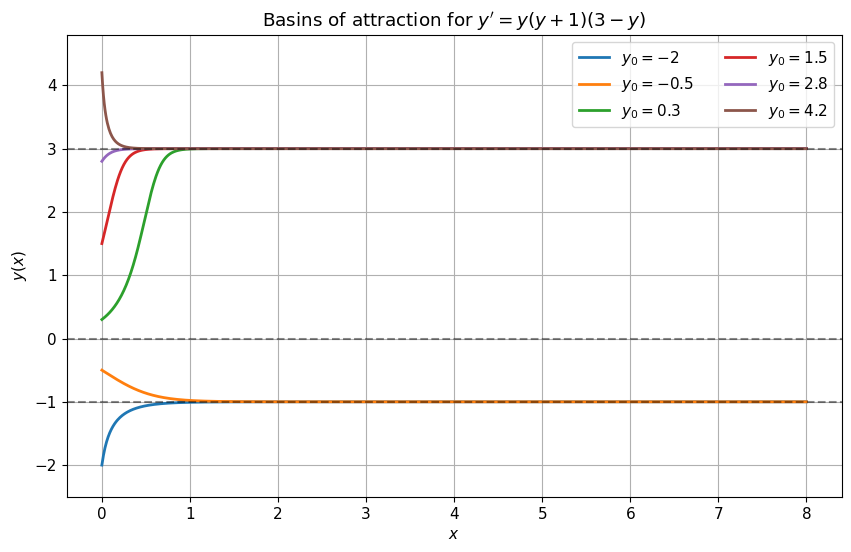

In [5]:
def cubic_rhs(t, y):
    return [y[0]*(y[0]+1)*(3-y[0])]

t_eval = np.linspace(0,8,900)
plt.figure(figsize=(10,6))
for y0 in [-2,-0.5,0.3,1.5,2.8,4.2]:
    sol = solve_ivp(cubic_rhs,(0,8),[y0],t_eval=t_eval,
                    rtol=1e-8,atol=1e-10)
    plt.plot(sol.t,sol.y[0],linewidth=2,label=fr"$y_0={y0}$")
for eq in [-1,0,3]:
    plt.axhline(eq,color="black",linestyle="--",alpha=0.45)
plt.xlabel("$x$")
plt.ylabel("$y(x)$")
plt.title(r"Basins of attraction for $y'=y(y+1)(3-y)$")
plt.legend(ncol=2)
plt.ylim(-2.5,4.8)
plt.show()

## 5. Why solutions cannot cross equilibria

Suppose the IVP for an autonomous equation satisfies a uniqueness theorem.

If a nonconstant solution crossed an equilibrium $y=c$, then at the crossing point there would be two solutions through the same point:

1. the equilibrium solution $y\equiv c$;
2. the nonconstant solution.

That would contradict uniqueness.

Therefore, when uniqueness applies, a nonconstant solution cannot cross an equilibrium curve.  
This explains why each initial value remains trapped in its phase-line interval.

## 6. Semistability

Consider

$$
\boxed{y'=(y-1)^2.}
$$

The equilibrium is

$$
y=1.
$$

Since

$$
(y-1)^2>0
$$

for every $y\ne1$, arrows point upward on **both** sides.

Thus:

- below $1$, solutions move upward toward the equilibrium;
- above $1$, solutions move upward away from the equilibrium.

So $y=1$ is **semistable**.

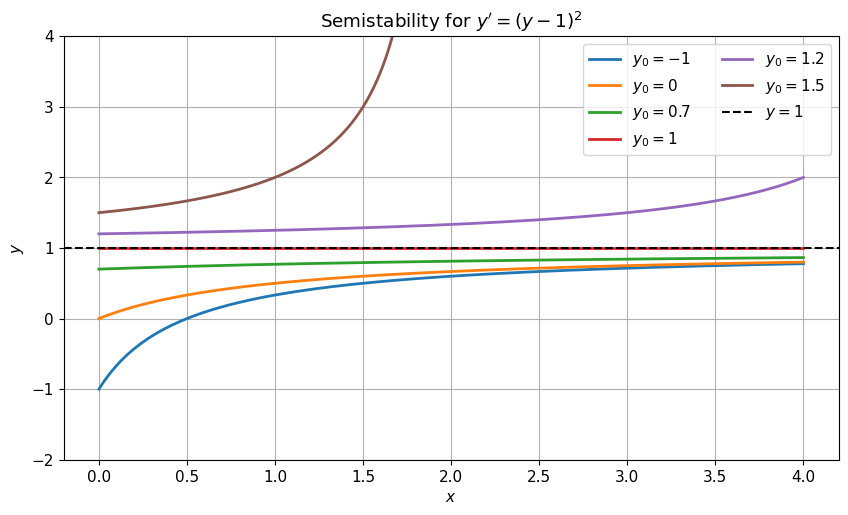

In [6]:
def semi_rhs(t,y):
    return [(y[0]-1)**2]

plt.figure(figsize=(10,5.5))
for y0 in [-1,0,0.7,1,1.2,1.5]:
    sol=solve_ivp(semi_rhs,(0,4),[y0],dense_output=True,max_step=0.02)
    tt=np.linspace(0,4,500)
    yy=sol.sol(tt)[0]
    yy=np.clip(yy,-3,5)
    plt.plot(tt,yy,linewidth=2,label=fr"$y_0={y0}$")
plt.axhline(1,color="black",linestyle="--",label="$y=1$")
plt.ylim(-2,4)
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.title(r"Semistability for $y'=(y-1)^2$")
plt.legend(ncol=2)
plt.show()

## 7. Translation property of autonomous equations

If $y(x)$ solves

$$
y'=f(y),
$$

then every horizontal translate

$$
y_k(x)=y(x-k)
$$

also solves the same autonomous equation.

For the logistic equation

$$
y'=y(1-y),
$$

the family

$$
y(x)=\frac{1}{1+Ce^{-x}}
$$

contains horizontal translations of the same basic sigmoid shape.

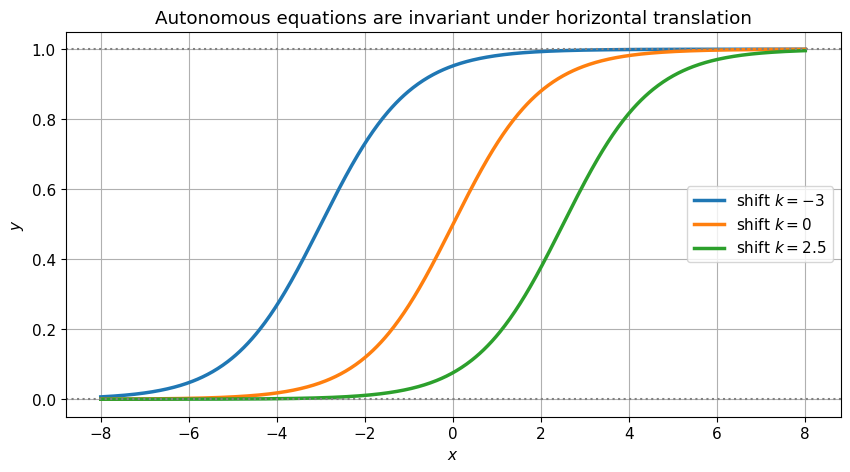

In [7]:
x=np.linspace(-8,8,700)
plt.figure(figsize=(10,5))
for k in [-3,0,2.5]:
    y=1/(1+np.exp(-(x-k)))
    plt.plot(x,y,linewidth=2.5,label=fr"shift $k={k}$")
plt.axhline(0,color="gray",linestyle=":")
plt.axhline(1,color="gray",linestyle=":")
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.title("Autonomous equations are invariant under horizontal translation")
plt.legend()
plt.show()

## 8. Interactive basin exploration

For

$$
y'=y(y+1)(3-y),
$$

change the initial value and compare the numerical trajectory with the phase-line prediction.

In [8]:
def explore_autonomous(y0=1.0, final_time=8.0):
    sol=solve_ivp(
        lambda t,y:[y[0]*(y[0]+1)*(3-y[0])],
        (0,final_time),[y0],dense_output=True,max_step=0.03
    )
    tt=np.linspace(0,final_time,600)
    yy=sol.sol(tt)[0]
    plt.figure(figsize=(9,5))
    plt.plot(tt,yy,linewidth=3)
    for eq in [-1,0,3]:
        plt.axhline(eq,color="black",linestyle="--",alpha=0.45)
    plt.xlabel("$x$")
    plt.ylabel("$y$")
    plt.title(fr"Trajectory from $y(0)={y0:.2f}$")
    plt.ylim(-3,5)
    plt.show()

interact(
    explore_autonomous,
    y0=FloatSlider(min=-2.5,max=4.5,step=0.1,value=1.0,description="$y_0$"),
    final_time=FloatSlider(min=2,max=12,step=1,value=8,description="time")
);

interactive(children=(FloatSlider(value=1.0, description='$y_0$', max=4.5, min=-2.5), FloatSlider(value=8.0, d…

## Classroom Checkpoint

Use only qualitative analysis; do not solve the differential equation.

In [ ]:
show_21_phase_line_check()

---

### Continue to the next section when ready.

# Section 2.2: Separable Equations

## 1. Recognizing a separable equation

A first-order equation is **separable** if it can be written as

$$
\boxed{\frac{dy}{dx}=g(x)h(y).}
$$

The method is based on moving all $y$-dependent factors to the $dy$ side and all $x$-dependent factors to the $dx$ side:

$$
\frac{1}{h(y)}\,dy=g(x)\,dx,
$$

provided

$$
h(y)\ne0.
$$

That restriction matters: values satisfying $h(y)=0$ may produce equilibrium solutions that must be recorded **before division**.

## 2. The separation procedure

For

$$
y'=g(x)h(y),
$$

use the following order:

1. solve
   $$
   h(y)=0
   $$
   to find possible constant solutions;
2. for nonconstant solutions, separate:
   $$
   \frac{1}{h(y)}\,dy=g(x)\,dx;
   $$
3. integrate both sides:
   $$
   \int\frac{1}{h(y)}\,dy
   =
   \int g(x)\,dx+C;
   $$
4. solve explicitly for $y$ if practical;
5. apply initial conditions;
6. determine the interval on which the resulting solution is valid.

## 3. Explicit example with finite-time blow-up

Solve

$$
\boxed{y'=x(1+y^2),\qquad y(0)=0.}
$$

Since

$$
1+y^2>0
$$

for all real $y$, there are no equilibrium solutions to recover.

Separate:

$$
\frac{dy}{1+y^2}=x\,dx.
$$

Integrate:

$$
\arctan y=\frac{x^2}{2}+C.
$$

Use $y(0)=0$:

$$
0=C.
$$

Therefore

$$
\boxed{y=\tan\left(\frac{x^2}{2}\right).}
$$

**A singular point is a value of the independent variable where a differential equation, or a particular solution formula, becomes undefined.**

The tangent function becomes singular when

$$
\frac{x^2}{2}=\frac{\pi}{2},
$$

so

$$
x=\pm\sqrt{\pi}.
$$

The largest interval containing the initial point $x=0$ is

$$
\boxed{(-\sqrt{\pi},\sqrt{\pi}).}
$$

This is an important distinction: the differential equation itself is smooth everywhere, but this particular solution blows up in finite time.

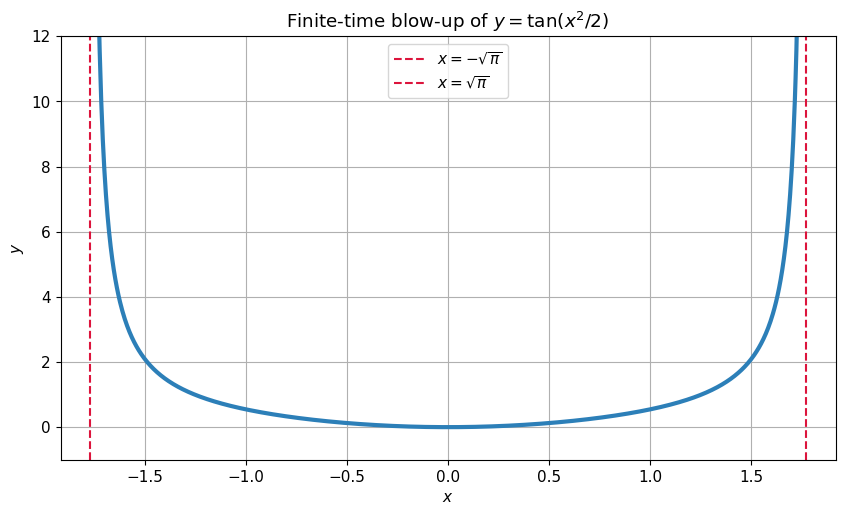

In [9]:
limit=np.sqrt(np.pi)
x=np.linspace(-limit+0.03,limit-0.03,900)
y=np.tan(x**2/2)
plt.figure(figsize=(10,5.5))
plt.plot(x,y,linewidth=3,color="#2c7fb8")
plt.axvline(-limit,color="crimson",linestyle="--",label=r"$x=-\sqrt{\pi}$")
plt.axvline(limit,color="crimson",linestyle="--",label=r"$x=\sqrt{\pi}$")
plt.ylim(-1,12)
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.title(r"Finite-time blow-up of $y=\tan(x^2/2)$")
plt.legend()
plt.show()

## 4. Implicit solutions and branch selection

Solve

$$
y\frac{dy}{dx}=-2x,
\qquad
y(1)=-2.
$$

Separate:

$$
y\,dy=-2x\,dx.
$$

Integrate:

$$
\frac{y^2}{2}=-x^2+C.
$$

Multiply by $2$:

$$
2x^2+y^2=C_1.
$$

Use $(1,-2)$:

$$
2(1)^2+(-2)^2=6,
$$

so the implicit solution is

$$
\boxed{2x^2+y^2=6.}
$$

The implicit curve has two explicit branches:

$$
y=\pm\sqrt{6-2x^2}.
$$

Because the initial condition has $y(1)=-2$, we must choose the negative branch:

$$
\boxed{y=-\sqrt{6-2x^2}.}
$$

The radicand must be positive for differentiability:

$$
6-2x^2>0,
$$

hence the maximal open interval containing $x=1$ is

$$
\boxed{(-\sqrt3,\sqrt3).}
$$

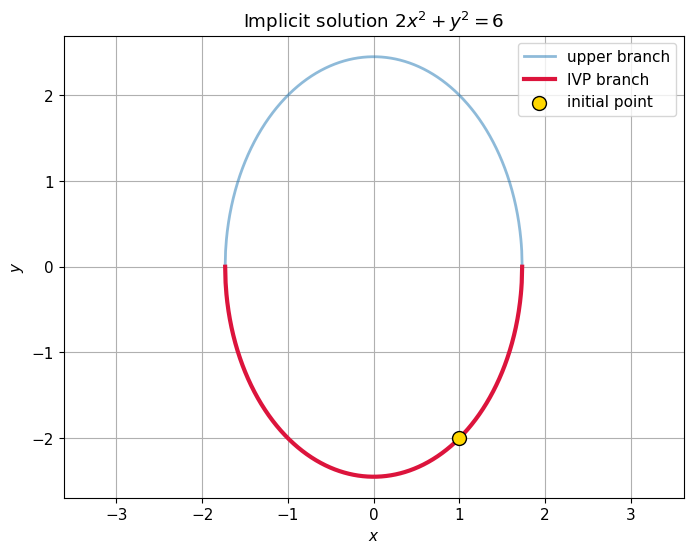

In [10]:
x=np.linspace(-np.sqrt(3),np.sqrt(3),700)
upper=np.sqrt(np.maximum(6-2*x**2,0))
lower=-upper
plt.figure(figsize=(8,6))
plt.plot(x,upper,linewidth=2,alpha=0.5,label="upper branch")
plt.plot(x,lower,linewidth=3,color="crimson",label="IVP branch")
plt.scatter([1],[-2],s=100,color="gold",edgecolor="black",zorder=5,label="initial point")
plt.axis("equal")
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.title(r"Implicit solution $2x^2+y^2=6$")
plt.legend()
plt.show()

## 5. Losing solutions by division

Consider

$$
\boxed{y'=x(y-2)(y+1).}
$$

Before dividing, solve

$$
(y-2)(y+1)=0.
$$

This gives the equilibrium solutions

$$
\boxed{y=2}
\qquad\text{and}\qquad
\boxed{y=-1}.
$$

Only after recording them should we divide by $(y-2)(y+1)$ to obtain the nonconstant family.

This is one of the most common errors in separation of variables.

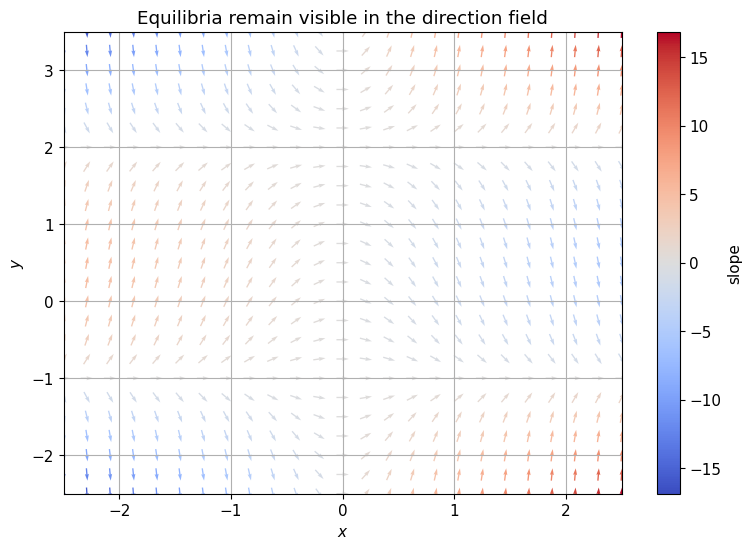

In [11]:
slope_field(
    lambda x,y: x*(y-2)*(y+1),
    xlim=(-2.5,2.5),ylim=(-2.5,3.5),density=25,
    title=r"Equilibria remain visible in the direction field"
)

## 6. Logistic Growth by Separation

### Background: Why Logistic Growth?

A simple model for population growth is the exponential equation

$$
P'=rP,
$$

where

* $P(t)$ is the population at time $t$,
* $P'(t)$ is the instantaneous rate of change of the population,
* $r>0$ is the intrinsic growth-rate parameter.

The exponential model assumes that the population has unlimited access to resources. Under this assumption, the growth rate remains proportional to the current population, and the population can grow without bound.

In many real populations, however, unlimited growth is not realistic. As the population becomes larger, resources such as food, water, space, or other necessities become increasingly limited. Competition increases, and the population growth rate begins to slow.

To incorporate this environmental limitation, we modify the exponential growth term $rP$ by multiplying it by the factor

$$
1-\frac{P}{K},
$$

where $K>0$ is called the **carrying capacity**.

The carrying capacity represents the population level that the environment can sustain over a long period of time.

This gives the **logistic growth equation**

$$
\boxed{
P'=rP\left(1-\frac{P}{K}\right),
}
$$

where

$$
r>0,
\qquad
K>0.
$$


### Interpreting the Logistic Growth Factor

The factor

$$
1-\frac{P}{K}
$$

controls how environmental limitations affect population growth.

If the population is much smaller than the carrying capacity,

$$
P\ll K,
$$

then

$$
\frac{P}{K}\approx0,
$$

so

$$
1-\frac{P}{K}\approx1.
$$

Therefore,

$$
P'
\approx
rP.
$$

Thus, when the population is small, the logistic model behaves approximately like exponential growth.

If

$$
0<P<K,
$$

then

$$
0<1-\frac{P}{K}<1,
$$

and therefore

$$
P'>0.
$$

The population is increasing, but the environmental limitation reduces the growth rate.

As

$$
P\to K,
$$

we have

$$
1-\frac{P}{K}\to0,
$$

so

$$
P'\to0.
$$

Therefore, the population grows more slowly as it approaches the carrying capacity.

If

$$
P>K,
$$

then

$$
1-\frac{P}{K}<0,
$$

so

$$
P'<0.
$$

In this case, the population decreases toward the carrying capacity.


### Equilibrium Solutions

Before separating variables, we should first determine whether the differential equation has any constant solutions.

An equilibrium occurs when

$$
P'=0.
$$

For the logistic equation,

$$
rP\left(1-\frac{P}{K}\right)=0.
$$

Since $r>0$, we must have either

$$
P=0
$$

or

$$
1-\frac{P}{K}=0.
$$

The second equation gives

$$
P=K.
$$

Thus the two equilibrium solutions are

$$
\boxed{
P(t)\equiv0
}
$$

and

$$
\boxed{
P(t)\equiv K.
}
$$

These solutions should be identified **before dividing** by expressions involving $P$ or $K-P$.

Otherwise, the separation process would remove these constant solutions from the calculation.

For nonconstant solutions, we assume

$$
P\neq0
\qquad\text{and}\qquad
P\neq K,
$$

and then proceed with separation of variables.


### Solving the Logistic Equation by Separation

For a nonconstant solution,

$$
\frac{dP}{dt}
=
rP\left(1-\frac{P}{K}\right).
$$

Separate the variables:

$$
\frac{dP}
{P\left(1-\frac{P}{K}\right)}
=
r\,dt.
$$

Since

$$
1-\frac{P}{K}
=
\frac{K-P}{K},
$$

we have

$$
P\left(1-\frac{P}{K}\right)
=
\frac{P(K-P)}{K}.
$$

Therefore,

$$
\frac{1}
{P\left(1-\frac{P}{K}\right)}
=
\frac{K}{P(K-P)}.
$$

Now use partial fractions:

$$
\frac{K}{P(K-P)}
=
\frac{A}{P}
+
\frac{B}{K-P}.
$$

Multiplying both sides by $P(K-P)$ gives

$$
K
=
A(K-P)+BP.
$$

Expanding,

$$
K
=
AK+(B-A)P.
$$

Comparing coefficients gives

$$
A=1
\qquad\text{and}\qquad
B=1.
$$

Thus,

$$
\boxed{
\frac{K}{P(K-P)}
=
\frac1P+\frac1{K-P}.
}
$$

The separated equation becomes

$$
\left(
\frac1P+\frac1{K-P}
\right)dP
=
r\,dt.
$$

Integrating both sides,

$$
\int
\left(
\frac1P+\frac1{K-P}
\right)dP
=
\int r\,dt.
$$

The first integral is

$$
\int\frac1P\,dP
=
\ln|P|.
$$

For the second integral,

$$
\int\frac1{K-P}\,dP,
$$

let

$$
u=K-P.
$$

Then

$$
du=-dP.
$$

Therefore,

$$
\int\frac1{K-P}\,dP
=
-\ln|K-P|.
$$

Hence,

$$
\ln|P|
-
\ln|K-P|
=
rt+C.
$$

Using logarithm properties,

$$
\ln\left|
\frac{P}{K-P}
\right|
=
rt+C.
$$

Exponentiating,

$$
\frac{P}{K-P}
=
C_1e^{rt},
$$

where $C_1\neq0$ is an arbitrary constant.

Solve for $P$:

$$
P
=
C_1e^{rt}(K-P).
$$

Thus,

$$
P+C_1e^{rt}P
=
KC_1e^{rt},
$$

so

$$
P\left(1+C_1e^{rt}\right)
=
KC_1e^{rt}.
$$

Therefore,

$$
P
=
\frac{KC_1e^{rt}}
{1+C_1e^{rt}}.
$$

Dividing numerator and denominator by $C_1e^{rt}$ gives

$$
P
=
\frac{K}
{1+\frac{1}{C_1}e^{-rt}}.
$$

Let

$$
A=\frac{1}{C_1}.
$$

Then the nonconstant logistic solutions are

$$
\boxed{
P(t)
=
\frac{K}
{1+Ae^{-rt}}.
}
$$


### Applying an Initial Condition

Suppose

$$
P(0)=P_0.
$$

Using

$$
P(t)
=
\frac{K}
{1+Ae^{-rt}},
$$

set $t=0$:

$$
P_0
=
\frac{K}{1+A}.
$$

Multiply both sides by $1+A$:

$$
P_0(1+A)=K.
$$

Therefore,

$$
1+A=\frac{K}{P_0},
$$

so

$$
A
=
\frac{K}{P_0}-1.
$$

Hence,

$$
\boxed{
A=\frac{K-P_0}{P_0}.
}
$$

The logistic solution satisfying

$$
P(0)=P_0
$$

is therefore

$$
\boxed{
P(t)
=
\frac{K}
{
1+
\left(
\frac{K-P_0}{P_0}
\right)e^{-rt}
}.
}
$$

### Long-Term Behavior

Since $r>0$,

$$
e^{-rt}\to0
\qquad\text{as}\qquad
t\to\infty.
$$

Therefore,

$$
P(t)
\to
\frac{K}{1+0}
=
K.
$$

Thus,

$$
\boxed{
\lim_{t\to\infty}P(t)=K.
}
$$

For

$$
0<P_0<K,
$$

the population increases toward $K$.

For

$$
P_0>K,
$$

the population decreases toward $K$.

Therefore, for positive initial populations other than the equilibrium $P_0=0$, the carrying capacity $K$ represents the long-term population level predicted by the logistic model.


In [13]:
def logistic_demo(P0=80.0,r=0.5,K=500.0):
    t=np.linspace(0,20,700)
    A=(K-P0)/P0
    P=K/(1+A*np.exp(-r*t))
    plt.figure(figsize=(10,5))
    plt.plot(t,P,linewidth=3,color="#238b45")
    plt.axhline(K,color="black",linestyle="--",label="$P=K$")
    plt.axhline(0,color="gray",linestyle=":")
    plt.scatter([0],[P0],s=90,color="gold",edgecolor="black")
    plt.xlabel("$t$")
    plt.ylabel("$P(t)$")
    plt.title("Logistic growth approaches the carrying capacity")
    plt.legend()
    plt.show()

interact(
    logistic_demo,
    P0=FloatSlider(min=10,max=450,step=10,value=80,description="$P_0$"),
    r=FloatSlider(min=0.1,max=1.0,step=0.05,value=0.5,description="$r$"),
    K=FloatSlider(min=200,max=800,step=50,value=500,description="$K$")
);

interactive(children=(FloatSlider(value=80.0, description='$P_0$', max=450.0, min=10.0, step=10.0), FloatSlide…

## 7. Exact solutions defined by integrals

Not every antiderivative can be written using elementary functions.

For

$$
y'=e^{-x^4},
\qquad
y(0)=1,
$$

integration gives the exact solution

$$
\boxed{
y(x)=1+\int_0^x e^{-t^4}\,dt.
}
$$

This is a completely valid exact answer even though the integral has no elementary antiderivative.

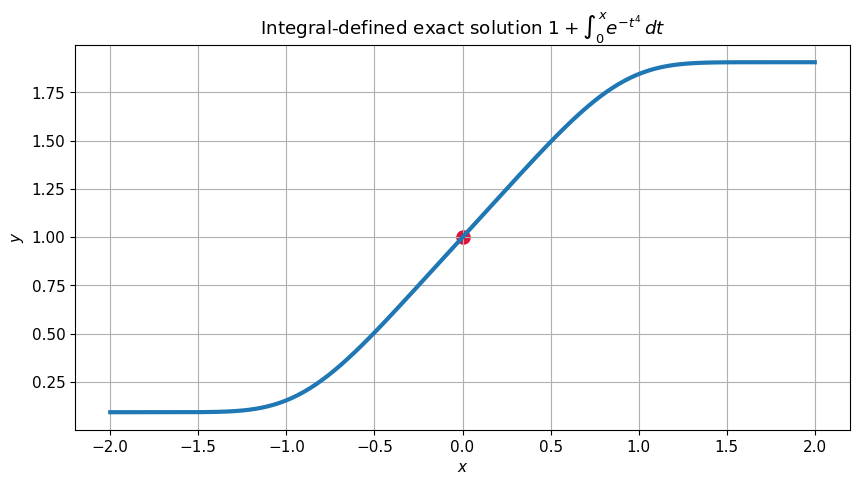

In [12]:
x_vals=np.linspace(-2,2,350)
y_vals=np.array([1+quad(lambda t:np.exp(-t**4),0,x)[0] for x in x_vals])
plt.figure(figsize=(10,5))
plt.plot(x_vals,y_vals,linewidth=3)
plt.scatter([0],[1],s=90,color="crimson")
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.title(r"Integral-defined exact solution $1+\int_0^x e^{-t^4}\,dt$")
plt.show()

## 8. Interactive blow-up experiment

For

$$
y'=y^2,
\qquad
y(0)=y_0,
$$

separation gives

$$
\boxed{
y(x)=\frac{y_0}{1-y_0x}.
}
$$

When $y_0>0$, the forward blow-up time is

$$
x=\frac1{y_0}.
$$

In [14]:
def separable_blowup(y0=1.0):
    plt.figure(figsize=(10,5))
    if abs(y0)<1e-10:
        x=np.linspace(-3,3,500)
        y=np.zeros_like(x)
        plt.plot(x,y,linewidth=3)
    else:
        singular=1/y0
        if singular>0:
            x=np.linspace(-2,singular-0.04,700)
        else:
            x=np.linspace(singular+0.04,3,700)
        y=y0/(1-y0*x)
        plt.plot(x,y,linewidth=3)
        plt.axvline(singular,color="crimson",linestyle="--",
                    label=fr"singularity $x={singular:.2f}$")
    plt.ylim(-10,10)
    plt.xlabel("$x$")
    plt.ylabel("$y$")
    plt.title(fr"$y'=y^2$, $y(0)={y0:.2f}$")
    plt.legend()
    plt.show()

interact(
    separable_blowup,
    y0=FloatSlider(min=-2,max=2,step=0.25,value=1.0,description="$y_0$")
);

interactive(children=(FloatSlider(value=1.0, description='$y_0$', max=2.0, min=-2.0, step=0.25), Output()), _d…

## Classroom Checkpoint

In [15]:
show_22_checkpoint()

### Problem 1

<IPython.core.display.Math object>

Solve the equation and make sure no constant solution is lost during separation.

---

### Continue to the next section when ready.

# Section 2.3: Linear First-Order Equations

## 1. Recognizing a linear first-order equation

A first-order equation is **linear in $y$** if it can be written as

$$
a_1(x)y'+a_0(x)y=g(x).
$$

Where

$$
a_1(x)\ne0,
$$

divide by $a_1(x)$ to obtain the standard form

$$
\boxed{y'+P(x)y=Q(x).}
$$

The values where $a_1(x)=0$ are potential singular points and must be considered before applying the integrating-factor method.

## 2. Why the integrating factor works

Start with

$$
y'+P(x)y=Q(x).
$$

Multiply by a function $\mu(x)$:

$$
\mu y'+\mu P y=\mu Q.
$$

We want the left side to be a product derivative:

$$
(\mu y)'=\mu y'+\mu' y.
$$

Therefore we need

$$
\mu'=\mu P.
$$

Divide by $\mu$:

$$
\frac{\mu'}{\mu}=P(x).
$$

Integrate:

$$
\ln|\mu|=\int P(x)\,dx.
$$

So we may choose

$$
\boxed{
\mu(x)=e^{\int P(x)\,dx}.
}
$$

Then

$$
\boxed{
(\mu y)'=\mu Q.
}
$$

## 3. Complete worked example

Solve

$$
\boxed{y'+2y=3x+1.}
$$

The equation is already in standard form:

$$
P(x)=2,
\qquad
Q(x)=3x+1.
$$

Therefore

$$
\mu(x)=e^{\int2\,dx}=e^{2x}.
$$

Multiply the equation by $e^{2x}$:

$$
e^{2x}y'+2e^{2x}y=(3x+1)e^{2x}.
$$

The left side is

$$
(e^{2x}y)'.
$$

Hence

$$
(e^{2x}y)'=(3x+1)e^{2x}.
$$

Integrate:

$$
e^{2x}y=\int(3x+1)e^{2x}\,dx+C.
$$

For the $3xe^{2x}$ term, use integration by parts:

$$
u=3x,
\qquad
dv=e^{2x}\,dx,
$$

so

$$
du=3\,dx,
\qquad
v=\frac12e^{2x}.
$$

Therefore

$$
\int3xe^{2x}\,dx
=
\frac32xe^{2x}
-
\frac32\int e^{2x}\,dx
=
\frac32xe^{2x}
-
\frac34e^{2x}.
$$

Also,

$$
\int e^{2x}\,dx=\frac12e^{2x}.
$$

Thus

$$
e^{2x}y
=
\frac32xe^{2x}
-\frac14e^{2x}
+C.
$$

Divide by $e^{2x}$:

$$
\boxed{
y=\frac32x-\frac14+Ce^{-2x}.
}
$$

In [16]:
x=sp.symbols("x",real=True)
C=sp.symbols("C")
y=sp.Rational(3,2)*x-sp.Rational(1,4)+C*sp.exp(-2*x)
residual=sp.simplify(sp.diff(y,x)+2*y-(3*x+1))
print("Residual:")
display(residual)

Residual:


0

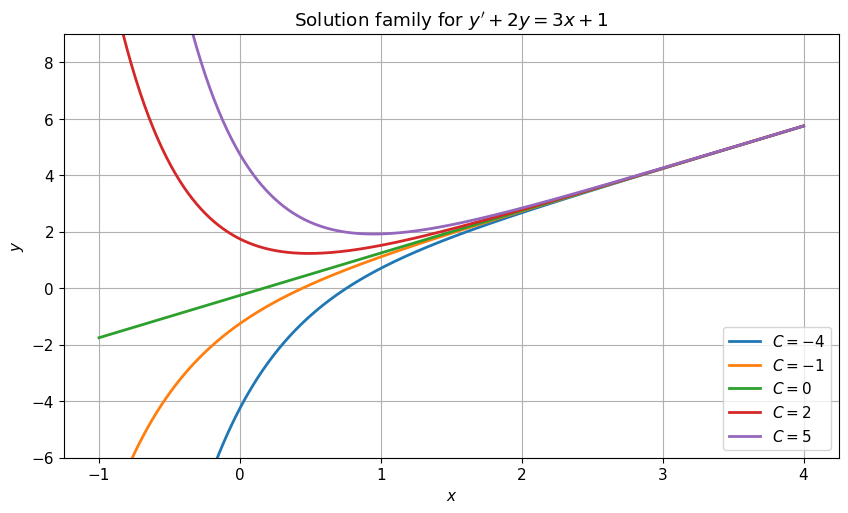

In [17]:
x_vals=np.linspace(-1,4,650)
plt.figure(figsize=(10,5.5))
for C_value in [-4,-1,0,2,5]:
    y_vals=1.5*x_vals-0.25+C_value*np.exp(-2*x_vals)
    plt.plot(x_vals,y_vals,linewidth=2,label=fr"$C={C_value}$")
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.title(r"Solution family for $y'+2y=3x+1$")
plt.ylim(-6,9)
plt.legend()
plt.show()

The solution naturally separates into

$$
y=y_p+y_h,
$$

where

$$
y_p=\frac32x-\frac14
$$

is a particular response and

$$
y_h=Ce^{-2x}
$$

is the homogeneous transient.

Since

$$
e^{-2x}\to0
\qquad(x\to\infty),
$$

all solutions approach the same particular response as $x$ increases.

## 4. Singular points and intervals

Consider

$$
xy'-2y=x^3.
$$

For

$$
x\ne0,
$$

divide by $x$:

$$
y'-\frac2x y=x^2.
$$

The coefficient

$$
-\frac2x
$$

is singular at

$$
x=0.
$$

Therefore the natural intervals are

$$
(-\infty,0)
\qquad\text{and}\qquad
(0,\infty).
$$

On either interval,

$$
\mu(x)
=
e^{\int -2/x\,dx}
=
e^{-2\ln|x|}
=
|x|^{-2}.
$$

Since a nonzero constant multiple of an integrating factor is still an integrating factor, we may use

$$
\boxed{\mu(x)=x^{-2}}
$$

on either interval.

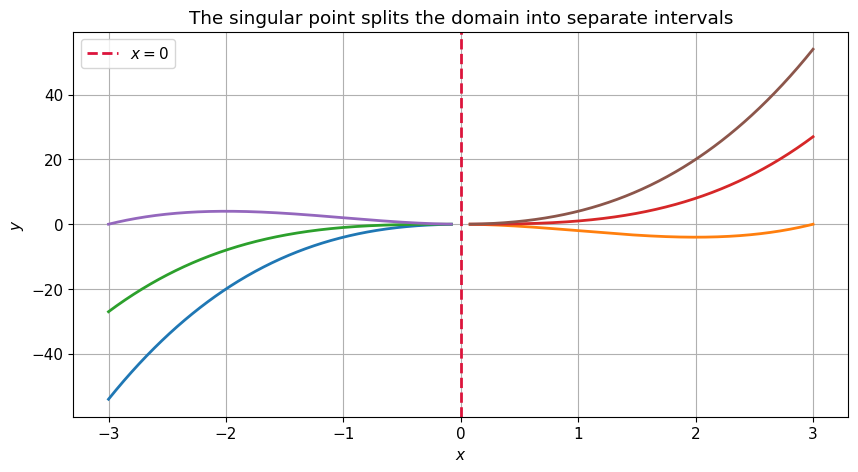

In [18]:
x_left=np.linspace(-3,-0.08,450)
x_right=np.linspace(0.08,3,450)
plt.figure(figsize=(10,5))
for C_value in [-3,0,3]:
    # Solve quickly: y=x^3+C*x^2
    plt.plot(x_left,x_left**3+C_value*x_left**2,linewidth=2)
    plt.plot(x_right,x_right**3+C_value*x_right**2,linewidth=2)
plt.axvline(0,color="crimson",linestyle="--",linewidth=2,label="$x=0$")
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.title("The singular point splits the domain into separate intervals")
plt.legend()
plt.show()

## 5. Piecewise forcing

Consider

$$
y'+y=f(t),
\qquad
y(0)=0,
$$

where

$$
f(t)=
\begin{cases}
1, & 0\le t<2,\\
3, & t\ge2.
\end{cases}
$$

For $0\le t<2$,

$$
y'+y=1,
$$

so

$$
y=1+Ce^{-t}.
$$

Using $y(0)=0$ gives

$$
C=-1,
$$

hence

$$
y=1-e^{-t}.
$$

At $t=2$,

$$
y(2)=1-e^{-2}.
$$

For $t\ge2$,

$$
y'+y=3,
$$

so

$$
y=3+De^{-t}.
$$

Continuity at $t=2$ determines $D$.

Require

$$
3+De^{-2}=1-e^{-2}.
$$

Thus

$$
De^{-2}=-2-e^{-2},
$$

so

$$
D=-2e^2-1.
$$

Therefore

$$
\boxed{
y(t)=
\begin{cases}
1-e^{-t}, & 0\le t<2,\\[1mm]
3-(2e^2+1)e^{-t}, & t\ge2.
\end{cases}
}
$$

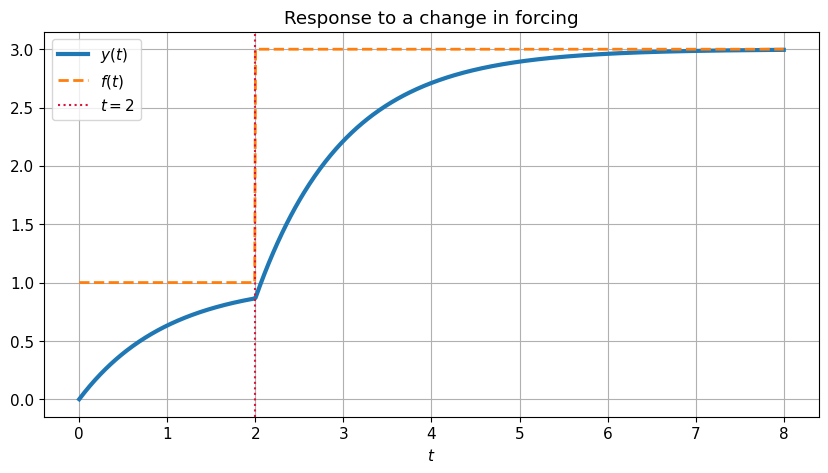

In [19]:
t=np.linspace(0,8,800)
forcing=np.where(t<2,1.0,3.0)
solution=np.where(t<2,1-np.exp(-t),3-(2*np.exp(2)+1)*np.exp(-t))
fig,ax=plt.subplots(figsize=(10,5))
ax.plot(t,solution,linewidth=3,label="$y(t)$")
ax.plot(t,forcing,linestyle="--",linewidth=2,label="$f(t)$")
ax.axvline(2,color="crimson",linestyle=":",label="$t=2$")
ax.set_xlabel("$t$")
ax.set_title("Response to a change in forcing")
ax.legend()
plt.show()

## 6. A nonelementary integral

Solve

$$
y'-2xy=1,
\qquad
y(0)=0.
$$

Here

$$
P(x)=-2x,
$$

so

$$
\mu(x)=e^{\int-2x\,dx}=e^{-x^2}.
$$

Therefore

$$
(e^{-x^2}y)'=e^{-x^2}.
$$

Integrating from $0$ to $x$ automatically incorporates the initial condition:

$$
e^{-x^2}y
=
\int_0^x e^{-t^2}\,dt.
$$

Hence

$$
\boxed{
y(x)=e^{x^2}\int_0^x e^{-t^2}\,dt.
}
$$

### The Error Function

In the example

$$
y'-2xy=1,
\qquad
y(0)=0,
$$

the integrating-factor method leads to

$$
y(x)
=
e^{x^2}
\int_0^x e^{-t^2}\,dt.
$$

The integral

$$
\int_0^x e^{-t^2}\,dt
$$

is important because it cannot be expressed using the usual elementary functions such as polynomials, exponentials, logarithms, trigonometric functions, or inverse trigonometric functions.

For this reason, a special function is introduced.

The **error function**, denoted by

$$
\operatorname{erf}(x),
$$

is defined by

$$
\boxed{
\operatorname{erf}(x)
=
\frac{2}{\sqrt{\pi}}
\int_0^x e^{-t^2}\,dt.
}
$$

The factor

$$
\frac{2}{\sqrt{\pi}}
$$

is chosen so that the error function has the convenient limiting values

$$
\lim_{x\to\infty}\operatorname{erf}(x)=1
$$

and

$$
\lim_{x\to-\infty}\operatorname{erf}(x)=-1.
$$

From the definition,

$$
\operatorname{erf}(0)=0.
$$

Also, because $e^{-t^2}$ is an even function,

$$
\operatorname{erf}(-x)
=
-\operatorname{erf}(x),
$$

so the error function is an odd function.

The definition can be rearranged as

$$
\int_0^x e^{-t^2}\,dt
=
\frac{\sqrt{\pi}}{2}
\operatorname{erf}(x).
$$

Therefore,

$$
y(x)
=
e^{x^2}
\int_0^x e^{-t^2}\,dt
$$

can be written as

$$
\boxed{
y(x)
=
\frac{\sqrt{\pi}}{2}
e^{x^2}
\operatorname{erf}(x).
}
$$

The error function appears frequently in applied mathematics, especially in problems involving

* diffusion,
* heat conduction,
* probability and statistics,
* Gaussian distributions.

For this course, the main point is that a solution of a differential equation may be perfectly exact even when it cannot be written entirely in elementary functions.


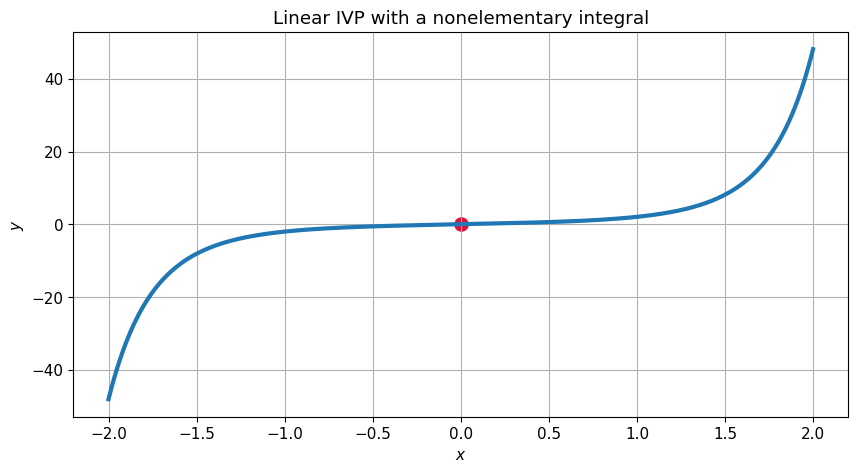

In [20]:
x_vals=np.linspace(-2,2,500)
y_vals=np.sqrt(np.pi)/2*np.exp(x_vals**2)*erf(x_vals)
plt.figure(figsize=(10,5))
plt.plot(x_vals,y_vals,linewidth=3)
plt.scatter([0],[0],s=90,color="crimson")
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.title("Linear IVP with a nonelementary integral")
plt.show()

## 7. Interactive transient decay

For

$$
y'+ay=3x+1,
\qquad a>0,
$$

the homogeneous part is

$$
Ce^{-ax}.
$$

Increasing $a$ makes this transient decay more rapidly.

In [21]:
def linear_response(a=2.0,C=3.0):
    x=np.linspace(0,6,650)
    alpha=3/a
    beta=(1-alpha)/a
    yp=alpha*x+beta
    y=yp+C*np.exp(-a*x)
    plt.figure(figsize=(10,5))
    plt.plot(x,y,linewidth=3,label="full solution")
    plt.plot(x,yp,"k--",linewidth=2,label="particular response")
    plt.xlabel("$x$")
    plt.ylabel("$y$")
    plt.title(fr"Transient $Ce^{{-ax}}$: $a={a:.2f}$")
    plt.legend()
    plt.show()

interact(
    linear_response,
    a=FloatSlider(min=0.4,max=4,step=0.2,value=2,description="$a$"),
    C=FloatSlider(min=-5,max=5,step=0.5,value=3,description="$C$")
);

interactive(children=(FloatSlider(value=2.0, description='$a$', max=4.0, min=0.4, step=0.2), FloatSlider(value…

## Classroom Checkpoint

In [ ]:
show_23_checkpoint()

---

### Continue to the next section when ready.

# Section 2.4: Exact Equations

## 1. Total differentials and hidden level curves

Let

$$
F=F(x,y)
$$

be differentiable. Its total differential is

$$
\boxed{
dF=F_x\,dx+F_y\,dy.
}
$$

If a curve is given implicitly by

$$
F(x,y)=C,
$$

then $F$ is constant along the curve, so

$$
dF=0.
$$

Therefore

$$
F_x\,dx+F_y\,dy=0.
$$

This is the geometric idea behind exact differential equations: an exact equation is describing a family of level curves of some potential function $F$.

## 2. Definition of exactness

Consider

$$
\boxed{
M(x,y)\,dx+N(x,y)\,dy=0.
}
$$

The equation is **exact** on a region if there exists a differentiable function $F(x,y)$ such that

$$
F_x=M
\qquad\text{and}\qquad
F_y=N.
$$

Then the differential equation becomes

$$
dF=0,
$$

so its implicit solution is

$$
\boxed{F(x,y)=C.}
$$

## 3. Exactness criterion

If $M$ and $N$ have continuous first partial derivatives on a rectangular region, exactness is equivalent to

$$
\boxed{M_y=N_x.}
$$

Why?

If

$$
M=F_x
\qquad\text{and}\qquad
N=F_y,
$$

then

$$
M_y=F_{xy},
$$

while

$$
N_x=F_{yx}.
$$

For a sufficiently smooth potential,

$$
F_{xy}=F_{yx},
$$

so

$$
M_y=N_x.
$$

## 4. Reconstructing the potential function

Suppose the equation is exact:

$$
M\,dx+N\,dy=0.
$$

Because

$$
F_x=M,
$$

integrate $M$ with respect to $x$:

$$
F(x,y)=\int M(x,y)\,dx+g(y).
$$

The term $g(y)$ must be included because differentiation with respect to $x$ would eliminate any function of $y$.

Next differentiate with respect to $y$:

$$
F_y=N.
$$

This determines $g'(y)$, and then $g(y)$.

## 5. Complete worked example

Solve

$$
\boxed{
(2xy-2)\,dx+(x^2+y^2)\,dy=0.
}
$$

Identify

$$
M=2xy-2,
\qquad
N=x^2+y^2.
$$

Check exactness:

$$
M_y=2x,
$$

and

$$
N_x=2x.
$$

Therefore

$$
M_y=N_x,
$$

so the equation is exact.

Since

$$
F_x=2xy-2,
$$

integrate with respect to $x$:

$$
F(x,y)
=
\int(2xy-2)\,dx
=
x^2y-2x+g(y).
$$

Differentiate with respect to $y$:

$$
F_y=x^2+g'(y).
$$

Set this equal to

$$
N=x^2+y^2:
$$

$$
x^2+g'(y)=x^2+y^2.
$$

Hence

$$
g'(y)=y^2,
$$

so

$$
g(y)=\frac{y^3}{3}.
$$

Therefore

$$
\boxed{
x^2y-2x+\frac{y^3}{3}=C.
}
$$

In [22]:
x,y=sp.symbols("x y",real=True)
F=x**2*y-2*x+y**3/3
print("F_x:")
display(sp.diff(F,x))
print("F_y:")
display(sp.diff(F,y))

F_x:


2*x*y - 2

F_y:


x**2 + y**2

### Quick Review: Gradient

For a differentiable function

$$
F(x,y),
$$

the **gradient** of $F$ is the vector of first partial derivatives:

$$
\boxed{
\nabla F(x,y)
=
\left\langle
\frac{\partial F}{\partial x},
\frac{\partial F}{\partial y}
\right\rangle
=
\langle F_x,F_y\rangle.
}
$$

The symbol

$$
\nabla
$$

is read **“del”** or **“nabla.”**

The gradient has two important geometric properties:

* $\nabla F$ points in the direction in which $F$ increases most rapidly.
* $\nabla F$ is perpendicular to the level curve

$$
F(x,y)=C.
$$

For example, if

$$
F(x,y)=x^2+y^2,
$$

then

$$
F_x=2x,
\qquad
F_y=2y,
$$

so

$$
\boxed{
\nabla F=\langle 2x,2y\rangle.
}
$$

The level curves

$$
x^2+y^2=C
$$

are circles, and the gradient vectors point perpendicular to these circles.

This idea is useful for exact differential equations. If

$$
F_x=M
\qquad\text{and}\qquad
F_y=N,
$$

then

$$
\boxed{
\nabla F=\langle M,N\rangle,
}
$$

and the implicit solution

$$
F(x,y)=C
$$

is a level curve of the potential function $F$.


## 6. Geometric interpretation: gradient versus level curve

For the potential

$$
F(x,y)=x^2y-2x+\frac{y^3}{3},
$$

the gradient is

$$
\nabla F=(F_x,F_y)=(M,N).
$$

A gradient vector is perpendicular to a level curve

$$
F(x,y)=C.
$$

So the exact differential equation

$$
M\,dx+N\,dy=0
$$

says that solution motion is tangent to the level curve and therefore orthogonal to the gradient.

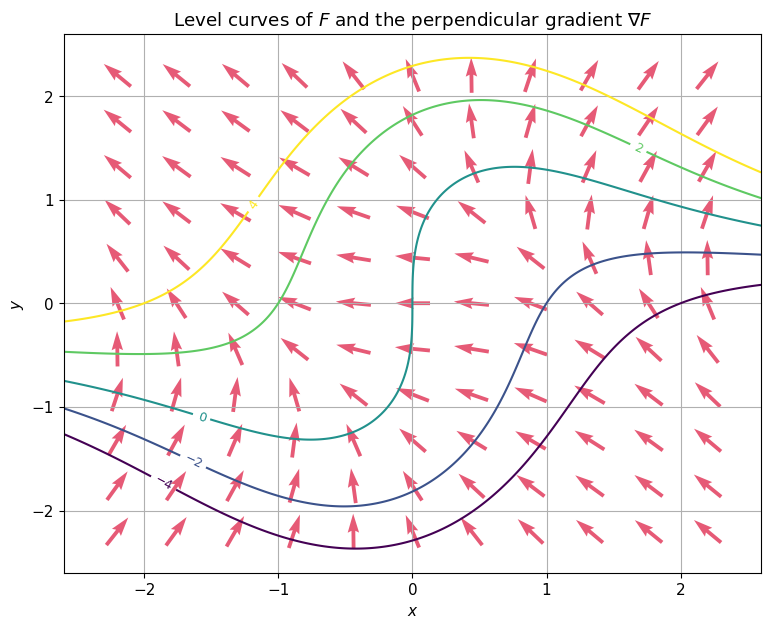

In [23]:
x_vals=np.linspace(-2.6,2.6,350)
y_vals=np.linspace(-2.6,2.6,350)
X,Y=np.meshgrid(x_vals,y_vals)
Fvals=X**2*Y-2*X+Y**3/3

plt.figure(figsize=(9,7))
contours=plt.contour(X,Y,Fvals,levels=[-4,-2,0,2,4],cmap="viridis")
plt.clabel(contours,inline=True,fontsize=9)

# A sparse gradient field
Xs=np.linspace(-2.2,2.2,11)
Ys=np.linspace(-2.2,2.2,11)
XX,YY=np.meshgrid(Xs,Ys)
Fx=2*XX*YY-2
Fy=XX**2+YY**2
N=np.sqrt(Fx**2+Fy**2)
N[N==0]=1
plt.quiver(XX,YY,Fx/N,Fy/N,color="crimson",alpha=0.7,pivot="mid")

plt.xlabel("$x$")
plt.ylabel("$y$")
plt.title(r"Level curves of $F$ and the perpendicular gradient $\nabla F$")
plt.show()

## 7. A second exact equation

Consider

$$
(3x^2+2y)\,dx+(2x+4y^3)\,dy=0.
$$

Here

$$
M_y=2,
\qquad
N_x=2,
$$

so the equation is exact.

Integrate

$$
F_x=3x^2+2y
$$

with respect to $x$:

$$
F=x^3+2xy+g(y).
$$

Differentiate:

$$
F_y=2x+g'(y).
$$

Matching

$$
N=2x+4y^3
$$

gives

$$
g'(y)=4y^3,
$$

hence

$$
g(y)=y^4.
$$

Therefore

$$
\boxed{x^3+2xy+y^4=C.}
$$

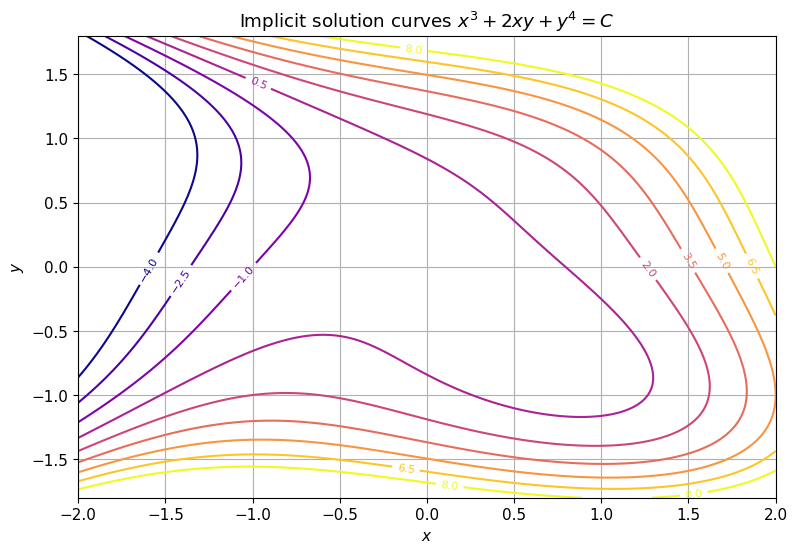

In [24]:
x_vals=np.linspace(-2,2,350)
y_vals=np.linspace(-1.8,1.8,350)
X,Y=np.meshgrid(x_vals,y_vals)
Fvals=X**3+2*X*Y+Y**4
plt.figure(figsize=(9,6))
cs=plt.contour(X,Y,Fvals,levels=np.linspace(-4,8,9),cmap="plasma")
plt.clabel(cs,inline=True,fontsize=8)
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.title(r"Implicit solution curves $x^3+2xy+y^4=C$")
plt.show()



## 8. Making a Nonexact Equation Exact: Finding an Integrating Factor

Consider

$$
\boxed{
y\,dx+(2x-y^2)\,dy=0.
}
$$

We identify

$$
M(x,y)=y
$$

and

$$
N(x,y)=2x-y^2.
$$

Recall that an equation

$$
M(x,y)\,dx+N(x,y)\,dy=0
$$

is exact if

$$
\boxed{
M_y=N_x.
}
$$

So our first step is always to check exactness.

For this equation,

$$
M_y
=
\frac{\partial}{\partial y}(y)
=
1,
$$

while

$$
N_x
=
\frac{\partial}{\partial x}(2x-y^2)
=
2.
$$

Since

$$
M_y\neq N_x,
$$

the equation is **not exact**.

Therefore, there is no function $F(x,y)$ satisfying

$$
F_x=M
\qquad\text{and}\qquad
F_y=N
$$

for the equation in its present form.

---

### Can We Make the Equation Exact?

Sometimes a nonexact equation can be converted into an exact equation by multiplying the entire differential equation by a suitable nonzero function.

Such a function is called an **integrating factor**.

Suppose we multiply

$$
M\,dx+N\,dy=0
$$

by a function $\mu$:

$$
\mu M\,dx+\mu N\,dy=0.
$$

We would like the new equation to be exact.

Therefore, the new coefficient functions must satisfy

$$
\boxed{
\frac{\partial}{\partial y}(\mu M)
=
\frac{\partial}{\partial x}(\mu N).
}
$$

The question is:

> How should we choose $\mu$ so that this equality holds?

In general, finding an integrating factor can be difficult. However, there are two particularly useful special cases:

1. $\mu$ depends only on $x$;
2. $\mu$ depends only on $y$.

For this example, we will investigate whether an integrating factor depending only on $y$ exists.

---

### Assume the Integrating Factor Depends Only on $y$

Suppose

$$
\mu=\mu(y).
$$

After multiplying the original equation by $\mu(y)$, we obtain

$$
\mu(y)M(x,y)\,dx
+
\mu(y)N(x,y)\,dy
=
0.
$$

For this new equation to be exact, we require

$$
\frac{\partial}{\partial y}
\bigl(\mu M\bigr)
=
\frac{\partial}{\partial x}
\bigl(\mu N\bigr).
$$

Let us compute both sides carefully.

Because $\mu$ depends on $y$, the left-hand side requires the product rule:

$$
\frac{\partial}{\partial y}
(\mu M)
=
\mu' M+\mu M_y.
$$

On the right-hand side, $\mu(y)$ is constant with respect to $x$. Therefore,

$$
\frac{\partial}{\partial x}
(\mu N)
=
\mu N_x.
$$

Thus the exactness condition becomes

$$
\mu' M+\mu M_y
=
\mu N_x.
$$

Move the term $\mu M_y$ to the right:

$$
\mu'M
=
\mu N_x-\mu M_y.
$$

Factor out $\mu$:

$$
\mu'M
=
\mu(N_x-M_y).
$$

Now divide by $\mu M$, assuming both are nonzero:

$$
\frac{\mu'}{\mu}
=
\frac{N_x-M_y}{M}.
$$

Therefore,

$$
\boxed{
\frac{\mu'(y)}{\mu(y)}
=
\frac{N_x-M_y}{M}.
}
$$

This equation explains why we calculate

$$
\boxed{
\frac{N_x-M_y}{M}.
}
$$

We are checking whether the right-hand side depends **only on $y$**.

Why?

Because the left-hand side,

$$
\frac{\mu'(y)}{\mu(y)},
$$

is a function of $y$ only.

Therefore, if

$$
\frac{N_x-M_y}{M}
$$

also depends only on $y$, then we can solve for an integrating factor $\mu(y)$.

---

### Apply the Test to This Equation

For our equation,

$$
M=y,
\qquad
N=2x-y^2.
$$

We already found

$$
M_y=1
$$

and

$$
N_x=2.
$$

Therefore,

$$
\frac{N_x-M_y}{M}
=
\frac{2-1}{y}
=
\boxed{\frac1y}.
$$

Notice that

$$
\frac1y
$$

depends only on $y$.

This is exactly what we were hoping for.

Therefore, an integrating factor of the form

$$
\mu=\mu(y)
$$

exists.

From the formula

$$
\frac{\mu'}{\mu}
=
\frac1y,
$$

we separate the variables:

$$
\frac{d\mu}{\mu}
=
\frac{dy}{y}.
$$

Integrating both sides gives

$$
\int\frac{d\mu}{\mu}
=
\int\frac{dy}{y}.
$$

Hence,

$$
\ln|\mu|
=
\ln|y|+C.
$$

Exponentiating,

$$
|\mu|
=
e^C|y|.
$$

Since an integrating factor is only determined up to a nonzero multiplicative constant, we may ignore the constant $e^C$.

Thus we may choose

$$
\mu(y)=|y|.
$$

On any region that does not cross $y=0$, such as

$$
y>0
$$

or

$$
y<0,
$$

we can use the simpler integrating factor

$$
\boxed{
\mu(y)=y.
}
$$

The restriction to a region with $y\neq0$ is important because the expression

$$
\frac1y
$$

used in deriving the integrating factor is not defined at $y=0$.

---

### Why This Worked

The quantity

$$
\frac{N_x-M_y}{M}
$$

was not chosen arbitrarily.

It came directly from imposing the exactness condition on the modified equation

$$
\mu(y)M\,dx+\mu(y)N\,dy=0.
$$

Whenever

$$
\boxed{
\frac{N_x-M_y}{M}
}
$$

is a function of $y$ alone, say

$$
\frac{N_x-M_y}{M}=g(y),
$$

an integrating factor depending only on $y$ is

$$
\boxed{
\mu(y)
=
e^{\int g(y)\,dy}.
}
$$

For this example,

$$
g(y)=\frac1y,
$$

so

$$
\mu(y)
=
e^{\int \frac1y\,dy}
=
e^{\ln|y|}
=
|y|,
$$

and we may take

$$
\boxed{\mu(y)=y}
$$

on a region where $y\neq0$.


Multiplying the equation by $y$ gives

$$
y^2\,dx+(2xy-y^3)\,dy=0.
$$

Now

$$
\widetilde M=y^2,
\qquad
\widetilde N=2xy-y^3.
$$

Check:

$$
\widetilde M_y=2y,
$$

and

$$
\widetilde N_x=2y.
$$

The transformed equation is exact.

Integrate

$$
F_x=y^2
$$

to obtain

$$
F=xy^2+g(y).
$$

Then

$$
F_y=2xy+g'(y)=2xy-y^3,
$$

so

$$
g'(y)=-y^3,
$$

and therefore

$$
g(y)=-\frac{y^4}{4}.
$$

Hence

$$
\boxed{
xy^2-\frac{y^4}{4}=C.
}
$$

## 9. Interactive level-curve exploration

For

$$
F(x,y)=x^2y-2x+\frac{y^3}{3},
$$

changing $C$ selects a different implicit solution

$$
F(x,y)=C.
$$

In [25]:
def select_level(C=-2/3):
    x=np.linspace(-3,3,450)
    y=np.linspace(-3,3,450)
    X,Y=np.meshgrid(x,y)
    F=X**2*Y-2*X+Y**3/3
    plt.figure(figsize=(8,6))
    plt.contour(X,Y,F,levels=[C],colors="crimson",linewidths=3)
    plt.contour(X,Y,F,levels=np.linspace(C-4,C+4,9),
                cmap="Greys",alpha=0.35)
    plt.xlabel("$x$")
    plt.ylabel("$y$")
    plt.title(fr"Selected level curve $F(x,y)={C:.2f}$")
    plt.show()

interact(
    select_level,
    C=FloatSlider(min=-5,max=5,step=0.25,value=-2/3,description="$C$")
);

interactive(children=(FloatSlider(value=-0.6666666666666666, description='$C$', max=5.0, min=-5.0, step=0.25),…

## Classroom Checkpoint

In [ ]:
show_24_checkpoint()

---

### Continue to the next section when ready.

# Section 2.5: Solutions by Substitution

## 1. Substitution as Structure Recognition

A substitution is useful when a differential equation repeatedly contains the same expression or combination of variables.

The main idea is to replace that complicated expression by a new variable, usually called

$$
u.
$$

If the substitution is chosen well, the original differential equation can often be transformed into a simpler equation that we already know how to solve, such as

* a separable equation,
* a linear equation,
* or an autonomous equation.

The important skill is therefore not simply memorizing substitutions. It is learning to recognize the **structure** of the differential equation.

---

### Why Does a Substitution Help?

Suppose the original unknown function is

$$
y=y(x).
$$

After introducing a new variable

$$
u=u(x),
$$

we may be able to express $y$ in the form

$$
\boxed{
y=g(x,u(x)).
}
$$

Notice that $y$ now depends on $x$ in two ways:

1. directly through the variable $x$;
2. indirectly through the new function $u(x)$.

Therefore, when we differentiate $y$, we must account for both types of dependence.

Using the multivariable chain rule,

$$
\boxed{
\frac{dy}{dx}
=
\frac{\partial g}{\partial x}
+
\frac{\partial g}{\partial u}
\frac{du}{dx}.
}
$$

Using shorter notation,

$$
\boxed{
y'
=
g_x+g_u u'.
}
$$

This formula tells us how to replace the original derivative $y'$ with an expression involving the new unknown function $u$.

---

### Why Are There Two Terms?

Because

$$
y=g(x,u(x)),
$$

a change in $x$ affects $y$ in two different ways.

First, changing $x$ may change $g$ directly. This contribution is measured by

$$
g_x.
$$

Second, changing $x$ also changes

$$
u=u(x),
$$

which then changes $g$. This contribution is

$$
g_u\frac{du}{dx}.
$$

Adding these two contributions gives

$$
\frac{dy}{dx}
=
g_x+g_u\frac{du}{dx}.
$$

This is simply the chain rule for a function whose arguments themselves depend on $x$.

---

### A Simple Example of the Chain Rule

Suppose we make the substitution

$$
y=xu.
$$

Then

$$
g(x,u)=xu.
$$

We have

$$
g_x=u
$$

and

$$
g_u=x.
$$

Therefore,

$$
y'
=
g_x+g_u u'
=
u+xu'.
$$

Thus,

$$
\boxed{
y'=u+xu'.
}
$$

This is the derivative formula that appears when we use

$$
u=\frac{y}{x}.
$$

Similarly, suppose we use

$$
y=u^{-1}.
$$

Then

$$
y=\frac1u.
$$

Differentiating gives

$$
y'
=
-u^{-2}u'.
$$

This type of transformation appears in a Bernoulli equation when we use a substitution such as

$$
u=y^{1-n}.
$$

---

### What Are We Trying to Accomplish?

The goal of a substitution is not merely to replace one variable by another.

We want the substitution to transform the original equation into a form that is easier to recognize and solve.

Symbolically, we are trying to turn

$$
\text{complicated equation in }x\text{ and }y
$$

into

$$
\boxed{
\text{simpler equation in }x\text{ and }u.
}
$$

Ideally, after substitution we obtain something like

$$
u'=F(x)G(u),
$$

which is separable, or

$$
u'+P(x)u=Q(x),
$$

which is linear.

Once we solve for $u$, we substitute back to recover $y$.

Therefore, the general strategy is

$$
\boxed{
\text{Recognize structure}
\longrightarrow
\text{choose }u
\longrightarrow
\text{rewrite }y'
\longrightarrow
\text{solve for }u
\longrightarrow
\text{substitute back for }y.
}
$$

---

### How Do We Choose the Substitution?

Look for an expression that appears repeatedly in the differential equation.

For example, if the equation contains the ratio

$$
\frac{y}{x},
$$

then it is natural to try

$$
u=\frac{y}{x}.
$$

If the equation contains a Bernoulli term

$$
y^n,
$$

together with a linear term in $y$, then the substitution

$$
u=y^{1-n}
$$

may transform the equation into a linear equation.

If the same linear combination

$$
Ax+By+C
$$

appears repeatedly, then we may try

$$
u=Ax+By+C.
$$

In each case, the substitution is chosen because it matches a recognizable structure already present in the equation.

---

### Important Point

A good substitution should make the equation **simpler**, not merely different.

After making a substitution, always ask:

> Did the transformed equation become a type that I already know how to solve?

If the answer is yes, then the substitution was useful.

The three important substitution patterns we will study are

$$
\boxed{
u=\frac{y}{x}
}
$$

for certain homogeneous first-order equations,

$$
\boxed{
u=y^{1-n}
}
$$

for Bernoulli equations, and

$$
\boxed{
u=Ax+By+C
}
$$

when the differential equation repeatedly contains the same linear combination of $x$ and $y$.


## 2. Homogeneous First-Order Equations

### Definition of a Homogeneous Function

A function

$$
f(x,y)
$$

is called **homogeneous of degree $n$** if

$$
\boxed{
f(tx,ty)=t^n f(x,y)
}
$$

for every scalar $t$ for which the expression is defined.

For example,

$$
f(x,y)=x^2+xy+y^2
$$

is homogeneous of degree $2$ because

$$
f(tx,ty)
=
(tx)^2+(tx)(ty)+(ty)^2
$$

$$
=
t^2x^2+t^2xy+t^2y^2
$$

$$
=
t^2(x^2+xy+y^2)
$$

and therefore

$$
f(tx,ty)=t^2f(x,y).
$$

Similarly,

$$
f(x,y)=x+y
$$

is homogeneous of degree $1$, while

$$
f(x,y)=x^3+x^2y
$$

is homogeneous of degree $3$.

---

### Definition of a Homogeneous First-Order Differential Equation

A first-order differential equation written in differential form as

$$
\boxed{
M(x,y)\,dx+N(x,y)\,dy=0
}
$$

is called a **homogeneous first-order differential equation** if both

$$
M(x,y)
$$

and

$$
N(x,y)
$$

are homogeneous functions of the **same degree**.

Equivalently, if the equation can be written in normal form as

$$
\boxed{
\frac{dy}{dx}
=
F\left(\frac{y}{x}\right),
}
$$

then it is a homogeneous first-order differential equation.

The key feature is that the right-hand side depends on $x$ and $y$ only through the ratio

$$
\frac{y}{x}.
$$

---

### Why Does the Ratio $y/x$ Appear?

Suppose

$$
M(x,y)
$$

and

$$
N(x,y)
$$

are homogeneous of the same degree $n$.

From

$$
M(x,y)\,dx+N(x,y)\,dy=0,
$$

we obtain

$$
\frac{dy}{dx}
=
-\frac{M(x,y)}{N(x,y)}.
$$

Because both $M$ and $N$ have the same degree, divide their arguments by $x$.

Write

$$
x=x\cdot1
$$

and

$$
y=x\left(\frac{y}{x}\right).
$$

Using homogeneity,

$$
M(x,y)
=
M\left(
x,\,
x\frac{y}{x}
\right)
=
x^n
M\left(
1,\frac{y}{x}
\right),
$$

and similarly,

$$
N(x,y)
=
x^n
N\left(
1,\frac{y}{x}
\right).
$$

Therefore,

$$
\frac{dy}{dx}
=
-
\frac{
x^nM\left(1,\frac{y}{x}\right)
}{
x^nN\left(1,\frac{y}{x}\right)
}.
$$

The factor $x^n$ cancels:

$$
\frac{dy}{dx}
=
-
\frac{
M\left(1,\frac{y}{x}\right)
}{
N\left(1,\frac{y}{x}\right)
}.
$$

Thus the right-hand side depends only on

$$
\frac{y}{x}.
$$

So we can write

$$
\boxed{
y'
=
F\left(\frac{y}{x}\right).
}
$$

This explains why the substitution

$$
\boxed{
u=\frac{y}{x}
}
$$

is natural.

---

### The Homogeneous Substitution

Let

$$
\boxed{
u=\frac{y}{x}.
}
$$

Then

$$
y=ux.
$$

Remember that $u$ is now a function of $x$:

$$
u=u(x).
$$

Differentiate

$$
y=ux
$$

using the product rule:

$$
y'
=
u\frac{d}{dx}(x)
+
x\frac{du}{dx}.
$$

Therefore,

$$
\boxed{
y'=u+xu'.
}
$$

Substituting

$$
\frac{y}{x}=u
$$

and

$$
y'=u+xu'
$$

into

$$
y'
=
F\left(\frac{y}{x}\right)
$$

gives

$$
u+xu'=F(u).
$$

Subtract $u$:

$$
xu'=F(u)-u.
$$

Thus,

$$
\frac{du}{dx}
=
\frac{F(u)-u}{x}.
$$

This is separable:

$$
\boxed{
\frac{du}{F(u)-u}
=
\frac{dx}{x}.
}
$$

Therefore, the substitution

$$
u=\frac{y}{x}
$$

transforms a homogeneous first-order differential equation into a separable equation.

---

### Important Terminology

The word **homogeneous** has more than one meaning in differential equations.

For a linear equation such as

$$
y'+P(x)y=Q(x),
$$

the associated **homogeneous linear equation** is

$$
y'+P(x)y=0.
$$

Here, homogeneous means that the forcing term is zero.

In the present section, a **homogeneous first-order equation** refers instead to an equation whose right-hand side depends on the ratio

$$
\frac{y}{x},
$$

or equivalently, whose differential-form coefficients $M$ and $N$ are homogeneous functions of the same degree.

These are two different uses of the word **homogeneous**.


### Worked example

Solve

$$
\boxed{
y'=\frac{x+y}{x-y}.
}
$$

Because numerator and denominator are both homogeneous linear expressions in $x$ and $y$,

$$
\frac{x+y}{x-y}
=
\frac{1+y/x}{1-y/x}.
$$

Set

$$
u=\frac{y}{x},
\qquad
y=ux,
\qquad
y'=u+xu'.
$$

Then

$$
u+xu'
=
\frac{1+u}{1-u}.
$$

Subtract $u$:

$$
xu'
=
\frac{1+u}{1-u}-u.
$$

Combine terms:

$$
xu'
=
\frac{1+u-u+u^2}{1-u}
=
\frac{1+u^2}{1-u}.
$$

Separate variables:

$$
\frac{1-u}{1+u^2}\,du
=
\frac{dx}{x}.
$$

Integrate:

$$
\int\frac{1}{1+u^2}\,du
-
\int\frac{u}{1+u^2}\,du
=
\int\frac{dx}{x}.
$$

Thus

$$
\arctan u
-
\frac12\ln(1+u^2)
=
\ln|x|+C.
$$

Substitute back

$$
u=\frac{y}{x}.
$$

One implicit form is

$$
\boxed{
\arctan\left(\frac{y}{x}\right)
-
\frac12\ln\left(1+\frac{y^2}{x^2}\right)
=
\ln|x|+C.
}
$$

### Geometric Meaning of the Substitution $u=y/x$

The substitution

$$
u=\frac{y}{x}
$$

has a useful geometric interpretation.

If $u$ is held constant, say

$$
u=c,
$$

then

$$
\frac{y}{x}=c,
$$

so

$$
\boxed{y=cx.}
$$

Therefore, each constant value of $u$ corresponds to a straight line through the origin.

These lines are useful reference rays for understanding the homogeneous structure of the differential equation. They are **not necessarily solution curves** of the differential equation.

For

$$
y'=\frac{x+y}{x-y},
$$

we must also notice that the denominator is zero when

$$
x-y=0.
$$

Thus,

$$
\boxed{y=x}
$$

is a singular line of the differential equation: the slope is undefined there, and numerical solution curves cannot be continued through this line using the differential equation in normal form.


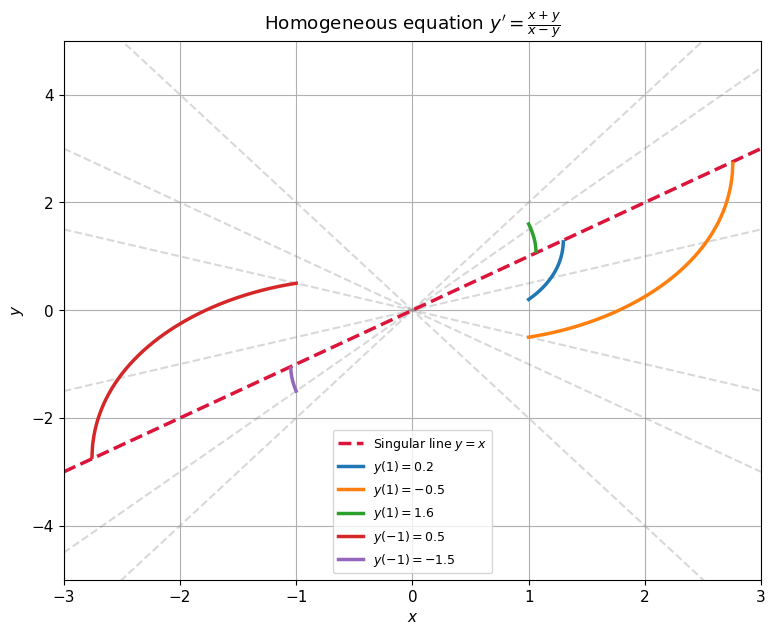

In [27]:
def homogeneous_rhs(x, y):
    return [(x + y[0]) / (x - y[0])]


# Stop the numerical solver before reaching the singular line y = x
def stop_near_singularity(x, y):
    eps = 0.03
    return (x - y[0])**2 - eps**2


stop_near_singularity.terminal = True
stop_near_singularity.direction = -1


plt.figure(figsize=(9, 7))


# ---------------------------------------------------------
# Reference rays: u = y/x = constant
# These are NOT solution curves.
# ---------------------------------------------------------

for slope in [-2, -1, -0.5, 0.5, 1.5, 2]:

    xx = np.linspace(-3, 3, 200)

    plt.plot(
        xx,
        slope * xx,
        color="gray",
        alpha=0.30,
        linestyle="--"
    )


# ---------------------------------------------------------
# Singular line y = x
# ---------------------------------------------------------

xx = np.linspace(-3, 3, 300)

plt.plot(
    xx,
    xx,
    color="crimson",
    linewidth=2.5,
    linestyle="--",
    label=r"Singular line $y=x$"
)


# ---------------------------------------------------------
# Numerical solution curves
# ---------------------------------------------------------

initial_conditions = [
    (1, 0.2),
    (1, -0.5),
    (1, 1.6),
    (-1, 0.5),
    (-1, -1.5)
]


for x0, y0 in initial_conditions:

    # Stay on the same side of x = 0
    if x0 > 0:
        end = 3
    else:
        end = -3

    sol = solve_ivp(
        homogeneous_rhs,
        (x0, end),
        [y0],
        dense_output=True,
        events=stop_near_singularity,
        max_step=0.01,
        rtol=1e-8,
        atol=1e-10
    )

    # IMPORTANT:
    # Evaluate only on the interval actually reached by the solver.
    x_end = sol.t[-1]

    xx = np.linspace(
        x0,
        x_end,
        400
    )

    yy = sol.sol(xx)[0]

    mask = (
        np.isfinite(yy)
        &
        (np.abs(yy) < 6)
    )

    plt.plot(
        xx[mask],
        yy[mask],
        linewidth=2.5,
        label=fr"$y({x0})={y0}$"
    )


plt.xlabel("$x$")
plt.ylabel("$y$")

plt.title(
    r"Homogeneous equation "
    r"$y'=\frac{x+y}{x-y}$"
)

plt.xlim(-3, 3)
plt.ylim(-5, 5)

plt.legend(
    loc="best",
    fontsize=9
)

plt.show()

## 3. Bernoulli equations

A Bernoulli equation has the form

$$
\boxed{
y'+P(x)y=Q(x)y^n,
\qquad n\ne0,1.
}
$$

Use

$$
\boxed{
u=y^{1-n}.
}
$$

Differentiate:

$$
u'
=
(1-n)y^{-n}y'.
$$

Now divide the Bernoulli equation by $y^n$:

$$
y^{-n}y'
+
P(x)y^{1-n}
=
Q(x).
$$

Since

$$
y^{-n}y'=\frac{u'}{1-n}
$$

and

$$
y^{1-n}=u,
$$

we get

$$
\frac{u'}{1-n}+P(x)u=Q(x).
$$

Multiply by $1-n$:

$$
\boxed{
u'+(1-n)P(x)u=(1-n)Q(x).
}
$$

The transformed equation is linear.

### Bernoulli example

Solve

$$
\boxed{
y'+y=xy^2.
}
$$

Here

$$
P(x)=1,
\qquad
Q(x)=x,
\qquad
n=2.
$$

Set

$$
u=y^{1-2}=y^{-1}.
$$

Then

$$
u'=-y^{-2}y'.
$$

Divide the original equation by $y^2$:

$$
y^{-2}y'+y^{-1}=x.
$$

Because

$$
y^{-2}y'=-u',
$$

we obtain

$$
-u'+u=x.
$$

Multiply by $-1$:

$$
\boxed{
u'-u=-x.
}
$$

Solve the linear equation

$$
u'-u=-x.
$$

The integrating factor is

$$
\mu=e^{-x}.
$$

Thus

$$
(e^{-x}u)'=-xe^{-x}.
$$

Integrating,

$$
e^{-x}u=(x+1)e^{-x}+C.
$$

Hence

$$
u=x+1+Ce^x.
$$

Since

$$
u=\frac1y,
$$

we obtain

$$
\boxed{
y=\frac{1}{x+1+Ce^x}.
}
$$

If the original Bernoulli equation admits the solution $y=0$, it must also be recorded separately because the substitution $u=1/y$ excludes it.

In [28]:
x,C=sp.symbols("x C",real=True)
y=1/(x+1+C*sp.exp(x))
residual=sp.simplify(sp.diff(y,x)+y-x*y**2)
print("Residual:")
display(residual)

Residual:


0

In [29]:
def bernoulli_family(C=0.5):
    x=np.linspace(-3,3,1500)
    denom=x+1+C*np.exp(x)
    y=np.where(np.abs(denom)>0.05,1/denom,np.nan)
    plt.figure(figsize=(10,5.5))
    plt.plot(x,y,linewidth=2.5)
    plt.axhline(0,color="black",linestyle="--",alpha=0.5,label="$y=0$")
    plt.ylim(-8,8)
    plt.xlabel("$x$")
    plt.ylabel("$y$")
    plt.title(fr"Bernoulli solution family, $C={C:.2f}$")
    plt.legend()
    plt.show()

interact(
    bernoulli_family,
    C=FloatSlider(min=-2,max=2,step=0.1,value=0.5,description="$C$")
);

interactive(children=(FloatSlider(value=0.5, description='$C$', max=2.0, min=-2.0), Output()), _dom_classes=('…

## 4. Substitution for a linear combination

If an equation contains

$$
Ax+By+C
$$

repeatedly, try

$$
\boxed{
u=Ax+By+C.
}
$$

Then

$$
u'=A+By'.
$$

If

$$
y'=F(Ax+By+C),
$$

the transformed equation becomes

$$
u'=A+B F(u),
$$

which is autonomous and therefore separable.

### Example

Solve

$$
y'=1+(x+y)^2,
\qquad
y(0)=0.
$$

Set

$$
u=x+y.
$$

Then

$$
u'=1+y'.
$$

Since

$$
y'=1+u^2,
$$

we get

$$
u'=2+u^2.
$$

Separate:

$$
\frac{du}{u^2+2}=dx.
$$

Integrate:

$$
\frac1{\sqrt2}
\arctan\left(\frac{u}{\sqrt2}\right)
=
x+C.
$$

The initial condition gives

$$
u(0)=0,
$$

so $C=0$. Therefore

$$
u=\sqrt2\tan(\sqrt2x).
$$

Since $u=x+y$,

$$
\boxed{
y=\sqrt2\tan(\sqrt2x)-x.
}
$$

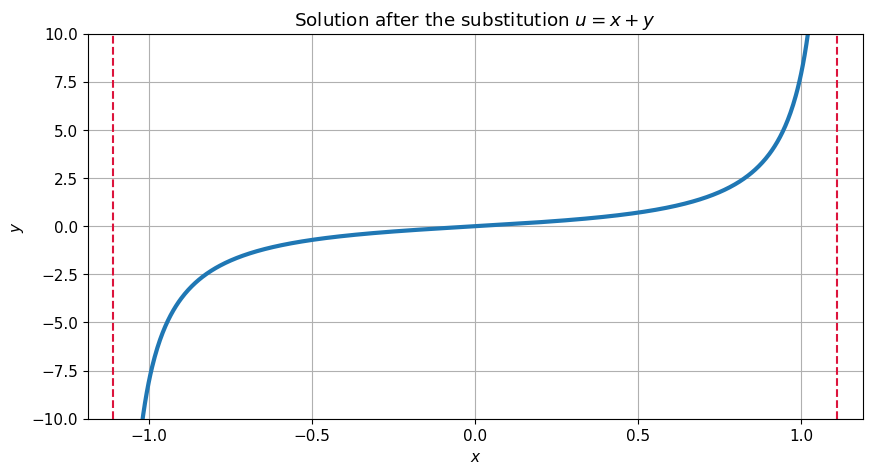

In [30]:
limit=np.pi/(2*np.sqrt(2))
x=np.linspace(-limit+0.03,limit-0.03,800)
y=np.sqrt(2)*np.tan(np.sqrt(2)*x)-x
plt.figure(figsize=(10,5))
plt.plot(x,y,linewidth=3)
plt.axvline(-limit,color="crimson",linestyle="--")
plt.axvline(limit,color="crimson",linestyle="--")
plt.ylim(-10,10)
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.title(r"Solution after the substitution $u=x+y$")
plt.show()

## 5. Method-selection guide

$$
\renewcommand{\arraystretch}{1.55}
\begin{array}{|c|c|}
\hline
\textbf{Recognizable structure} & \textbf{Method to try} \\
\hline
y'=g(x)h(y) & \text{separation} \\
\hline
y'+P(x)y=Q(x) & \text{integrating factor} \\
\hline
M\,dx+N\,dy=0,\; M_y=N_x & \text{exact equation} \\
\hline
y'=F(y/x) & u=y/x \\
\hline
y'+P(x)y=Q(x)y^n & u=y^{1-n} \\
\hline
y'=F(Ax+By+C) & u=Ax+By+C \\
\hline
\end{array}
$$

The important skill is not memorizing substitutions in isolation.  
It is identifying the structure that the substitution is designed to simplify.

## Classroom Checkpoint

In [ ]:
show_25_checkpoint()

---

### Continue to the next section when ready.

# Section 2.6: Euler's Numerical Method

## 1. Why Euler's method works

Consider the IVP

$$
y'=f(x,y),
\qquad
y(x_0)=y_0.
$$

Near the point $(x_n,y_n)$, the tangent-line approximation is

$$
y(x)
\approx
y_n+f(x_n,y_n)(x-x_n).
$$

Choose a step size $h$ and set

$$
x_{n+1}=x_n+h.
$$

Then

$$
y(x_{n+1})
\approx
y_n+h f(x_n,y_n).
$$

Euler's method defines the next approximation by

$$
\boxed{
x_{n+1}=x_n+h,
\qquad
y_{n+1}=y_n+h f(x_n,y_n).
}
$$

So each Euler step simply follows the current tangent line for a horizontal distance $h$.

## 2. Hand computation before coding

Apply Euler's method to

$$
\boxed{
y'=x+y,
\qquad
y(0)=1,
}
$$

with

$$
h=0.4.
$$

The exact solution is

$$
\boxed{
y=2e^x-x-1.
}
$$

### Step 0

$$
x_0=0,
\qquad
y_0=1.
$$

The slope is

$$
f(x_0,y_0)=0+1=1.
$$

Thus

$$
y_1
=
1+0.4(1)
=
1.4,
$$

and

$$
x_1=0.4.
$$

### Step 1

Now

$$
f(x_1,y_1)=0.4+1.4=1.8.
$$

Therefore

$$
y_2
=
1.4+0.4(1.8)
=
2.12,
$$

and

$$
x_2=0.8.
$$

The first few Euler values are therefore

$$
\renewcommand{\arraystretch}{1.5}
\begin{array}{|c|c|c|c|}
\hline
\textbf{Step }n & x_n & y_n & f(x_n,y_n) \\
\hline
0 & 0.0 & 1.0000 & 1.0000 \\
\hline
1 & 0.4 & 1.4000 & 1.8000 \\
\hline
2 & 0.8 & 2.1200 & 2.9200 \\
\hline
\end{array}
$$

The next update is

$$
y_3
=
2.12+0.4(2.92)
=
3.288.
$$

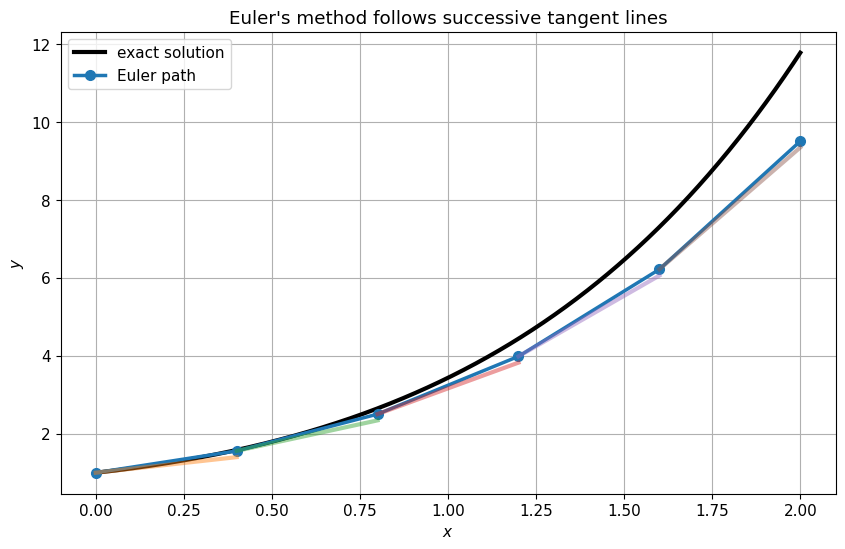

In [31]:
def f(x,y):
    return x+y

def exact(x):
    return 2*np.exp(x)-x-1

h=0.4
xs,ys=euler_method(f,0,1,h,5)

x_dense=np.linspace(0,2,700)
plt.figure(figsize=(10,6))
plt.plot(x_dense,exact(x_dense),linewidth=3,color="black",label="exact solution")
plt.plot(xs,ys,"o-",linewidth=2.5,markersize=7,label="Euler path")

# Draw the tangent segment used at each Euler step.
for n in range(len(xs)-1):
    xx=np.linspace(xs[n],xs[n+1],40)
    tangent=ys[n]+f(xs[n],ys[n])*(xx-xs[n])
    plt.plot(xx,tangent,linewidth=3,alpha=0.45)

plt.xlabel("$x$")
plt.ylabel("$y$")
plt.title(r"Euler's method follows successive tangent lines")
plt.legend()
plt.show()

## 3. Error at the computed points

At each node,

$$
\text{absolute error}
=
|y(x_n)-y_n|.
$$

The approximation error accumulates because every new step begins from the previous approximate value rather than the exact solution value.

In [32]:
exact_values=exact(xs)
absolute_error=np.abs(exact_values-ys)

rows=[]
for n,(xn,yn,ye,err) in enumerate(zip(xs,ys,exact_values,absolute_error)):
    rows.append((n,xn,yn,ye,err))

print(" n      x_n       Euler y_n      exact y(x_n)      abs. error")
for n,xn,yn,ye,err in rows:
    print(f"{n:2d}   {xn:7.3f}    {yn:11.6f}    {ye:13.6f}    {err:10.6f}")

 n      x_n       Euler y_n      exact y(x_n)      abs. error
 0     0.000       1.000000         1.000000      0.000000
 1     0.400       1.560000         1.583649      0.023649
 2     0.800       2.504000         2.651082      0.147082
 3     1.200       3.985600         4.440234      0.454634
 4     1.600       6.219840         7.306065      1.086225
 5     2.000       9.507776        11.778112      2.270336


## 4. Local and global error

Euler's method has **local truncation error**

$$
O(h^2)
$$

per step.

After approximately

$$
\frac{1}{h}
$$

steps over a fixed interval, these local errors accumulate to produce a **global error**

$$
\boxed{O(h).}
$$

Thus Euler's method is a **first-order method**.

When $h$ is sufficiently small, halving $h$ should approximately halve the global error.

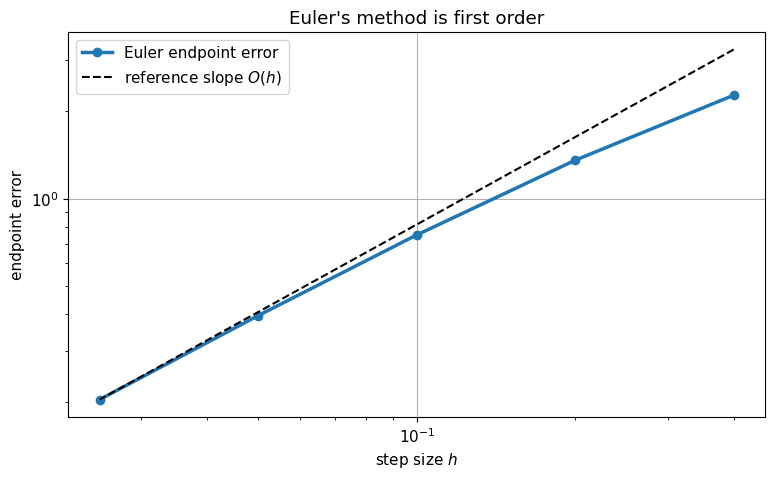

h= 0.4000   error=2.27033620
h= 0.2000   error=1.35629207
h= 0.1000   error=0.75036230
h= 0.0500   error=0.39613534
h= 0.0250   error=0.20373737


In [33]:
target=2.0
step_sizes=np.array([0.4,0.2,0.1,0.05,0.025])
errors=[]

for h in step_sizes:
    n_steps=int(round(target/h))
    xs,ys=euler_method(f,0,1,h,n_steps)
    errors.append(abs(exact(target)-ys[-1]))

plt.figure(figsize=(9,5))
plt.loglog(step_sizes,errors,"o-",linewidth=2.5,label="Euler endpoint error")
reference=errors[-1]*(step_sizes/step_sizes[-1])
plt.loglog(step_sizes,reference,"k--",label=r"reference slope $O(h)$")
plt.xlabel("step size $h$")
plt.ylabel("endpoint error")
plt.title("Euler's method is first order")
plt.legend()
plt.show()

for h,e in zip(step_sizes,errors):
    print(f"h={h:7.4f}   error={e:.8f}")

## 5. Interactive step-size comparison

The exact differential equation is unchanged; only the numerical step size changes.

Smaller $h$ generally tracks the exact solution more closely, but requires more steps.

In [34]:
def euler_comparison(h=0.25):
    target=2.0
    n_steps=int(np.ceil(target/h))
    h_adjusted=target/n_steps
    xs,ys=euler_method(f,0,1,h_adjusted,n_steps)

    xx=np.linspace(0,target,700)
    plt.figure(figsize=(10,5.5))
    plt.plot(xx,exact(xx),linewidth=3,color="black",label="exact")
    plt.plot(xs,ys,"o-",linewidth=2,label="Euler")
    plt.xlabel("$x$")
    plt.ylabel("$y$")
    plt.title(fr"$h\approx{h_adjusted:.4f}$, steps={n_steps}")
    plt.legend()
    plt.show()

    print("Endpoint error =",abs(exact(target)-ys[-1]))

interact(
    euler_comparison,
    h=FloatSlider(min=0.04,max=0.8,step=0.04,value=0.24,description="$h$")
);

interactive(children=(FloatSlider(value=0.24, description='$h$', max=0.8, min=0.04, step=0.04), Output()), _do…

## 6. Numerical stability is different from accuracy

Consider the stable differential equation

$$
\boxed{
y'=-8y,
\qquad
y(0)=1.
}
$$

The exact solution is

$$
y=e^{-8t},
$$

which decays monotonically to zero.

Euler's method gives

$$
y_{n+1}
=
y_n+h(-8y_n)
=
(1-8h)y_n.
$$

The numerical amplification factor is

$$
G=1-8h.
$$

For the Euler iterates to decay in magnitude, we need

$$
|G|<1.
$$

Thus

$$
|1-8h|<1,
$$

which gives

$$
\boxed{0<h<\frac14.}
$$

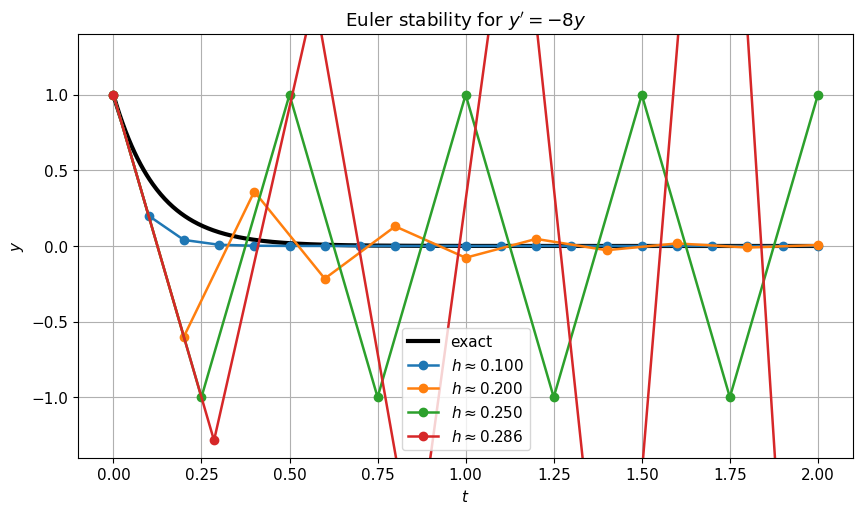

In [35]:
def decay_rhs(t,y):
    return -8*y

t_dense=np.linspace(0,2,700)
plt.figure(figsize=(10,5.5))
plt.plot(t_dense,np.exp(-8*t_dense),linewidth=3,color="black",label="exact")

for h in [0.1,0.22,0.25,0.3]:
    n=int(np.ceil(2/h))
    hh=2/n
    xs,ys=euler_method(decay_rhs,0,1,hh,n)
    plt.plot(xs,ys,"o-",linewidth=1.8,label=fr"$h\approx{hh:.3f}$")

plt.xlabel("$t$")
plt.ylabel("$y$")
plt.title(r"Euler stability for $y'=-8y$")
plt.ylim(-1.4,1.4)
plt.legend()
plt.show()

## 7. Euler versus an adaptive solver

A modern adaptive solver such as `solve_ivp` changes its step size automatically to control estimated local error.

Euler's method is much simpler, but it exposes the essential numerical ideas:

- slope evaluation,
- step size,
- accumulated error,
- computational cost,
- numerical stability.

These ideas reappear in more advanced methods.

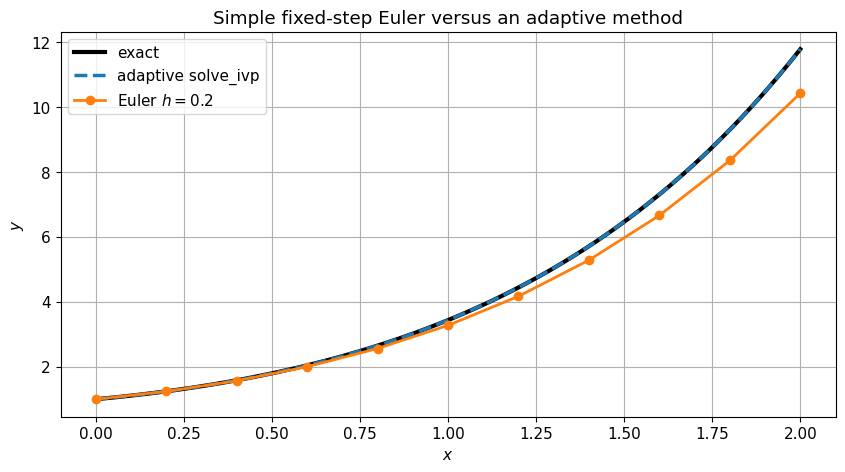

In [36]:
sol=solve_ivp(
    lambda x,y:[x+y[0]],
    (0,2),[1],
    rtol=1e-8,atol=1e-10,dense_output=True
)
x_dense=np.linspace(0,2,700)

plt.figure(figsize=(10,5))
plt.plot(x_dense,exact(x_dense),linewidth=3,color="black",label="exact")
plt.plot(x_dense,sol.sol(x_dense)[0],"--",linewidth=2.5,label="adaptive solve_ivp")
xs,ys=euler_method(f,0,1,0.2,10)
plt.plot(xs,ys,"o-",linewidth=2,label="Euler $h=0.2$")
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.title("Simple fixed-step Euler versus an adaptive method")
plt.legend()
plt.show()

## 8. Accuracy versus computational work

Reducing $h$ improves accuracy but increases the number of function evaluations.

The useful question is not simply

> Which method uses the smallest step?

but rather

> How much accuracy do we gain for the computational work we spend?

In [37]:
def accuracy_cost(h=0.2):
    target=2.0
    n_steps=int(np.ceil(target/h))
    hh=target/n_steps
    xs,ys=euler_method(f,0,1,hh,n_steps)
    err=abs(exact(target)-ys[-1])

    plt.figure(figsize=(8,4.5))
    plt.bar(["Euler steps","-log10(error)"],[n_steps,-np.log10(err)])
    plt.title(fr"$h\approx{hh:.4f}$: cost versus accuracy")
    plt.show()

    print(f"steps = {n_steps}")
    print(f"endpoint error = {err:.8e}")

interact(
    accuracy_cost,
    h=FloatSlider(min=0.02,max=0.6,step=0.02,value=0.2,description="$h$")
);

interactive(children=(FloatSlider(value=0.2, description='$h$', max=0.6, min=0.02, step=0.02), Output()), _dom…

## Classroom Checkpoint

In [ ]:
show_26_checkpoint()